In [ ]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ========= #
# GPU Check #
# ========= #

import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    props = torch.cuda.get_device_properties(0)

    print(
        "VRAM:",
        round(
            props.total_memory / (1024 ** 3),
            2,
        ),
        "GB",
    )

CUDA: True
GPU: Tesla T4
VRAM: 14.56 GB


In [11]:
# =================== #
# Colab Project Setup #
# =================== #

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/PersianSentimentProject"
)

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Working directory:", Path.cwd())
print("Project in sys.path:", str(PROJECT_ROOT) in sys.path)

Working directory: /content/drive/MyDrive/PersianSentimentProject
Project in sys.path: True


In [12]:
# ================ #
# Project Contents #
# ================ #

print("Project root:")
print(PROJECT_ROOT)

print("\nContents:")

for item in PROJECT_ROOT.iterdir():
    print("-", item.name)

Project root:
/content/drive/MyDrive/PersianSentimentProject

Contents:
- notebooks
- .hintrc
- reports
- fonts
- outputs
- data


In [13]:
# ================ #
# Find Notebook UI #
# ================ #

ui_matches = [
    path
    for path in PROJECT_ROOT.rglob("notebook_ui")
    if path.is_dir()
]

print("Matches:")

for path in ui_matches:
    print(path)

Matches:
/content/drive/MyDrive/PersianSentimentProject/notebooks/notebook_ui


In [14]:
# ============= #
# UI Path Setup #
# ============= #

NOTEBOOK_UI_PATH = ui_matches[0]

UI_PARENT = NOTEBOOK_UI_PATH.parent

if str(UI_PARENT) not in sys.path:
    sys.path.insert(
        0,
        str(UI_PARENT),
    )

os.chdir(UI_PARENT)

print("UI path:", NOTEBOOK_UI_PATH)
print("Working directory:", Path.cwd())

UI path: /content/drive/MyDrive/PersianSentimentProject/notebooks/notebook_ui
Working directory: /content/drive/MyDrive/PersianSentimentProject/notebooks


# ParsBERT Fine-Tuning for Persian Sentiment Analysis

In this stage, the ParsBERT model is fine-tuned for five-class sentiment analysis using the cleaned version of SentiPers .

**This notebook covers:**

- Preparing data for Transformer model input
- Tokenization using the official ParsBERT tokenizer
- Fine-tuning the model for five sentiment classes
- Evaluation using the same metrics as classic models
- Direct comparison between ParsBERT and Linear SVM


## ParsBERT Model List
- STEP 01 — Environment & Hardware
- STEP 02 — Configuration
- STEP 03 — Project Paths
- STEP 04 — Load Clean Dataset
- STEP 05 — Text & Labels
- STEP 06 — Stratified Split
- STEP 07 — ParsBERT Tokenizer
- STEP 08 — Token & UNK Analysis
- STEP 09 — Dataset Encoding
- STEP 10 — Load ParsBERT Model
- STEP 11 — Smoke Training Test
- STEP 12 — Training Configuration
- STEP 13 — Full Fine-Tuning
- STEP 14 — Final Test Evaluation
- STEP 15 — Model Comparison
- STEP 16 — Final Results
- END — Conclusion


## STEP 01 — Environment and Hardware Check

Before loading ParsBERT, the Python environment, PyTorch, memory, and accelerator status are checked.


In [17]:
import platform
import subprocess
import sys
from pathlib import Path

import psutil
import torch


def get_windows_gpu_info():
    """Read physical GPU information from Windows, independently of PyTorch."""
    if platform.system() != "Windows":
        return []

    command = (
        "Get-CimInstance Win32_VideoController | "
        "Select-Object Name, AdapterRAM | "
        "ConvertTo-Json -Compress"
    )

    try:
        result = subprocess.run(
            ["powershell", "-NoProfile", "-Command", command],
            capture_output=True,
            text=True,
            timeout=10,
        )

        if result.returncode != 0 or not result.stdout.strip():
            return []

        import json

        data = json.loads(result.stdout)

        if isinstance(data, dict):
            data = [data]

        return data

    except Exception:
        return []


gpu_info = get_windows_gpu_info()

environment_info = {
    "Python": platform.python_version(),
    "Operating System": platform.system(),
    "CPU": platform.processor() or "Unknown",
    "Logical CPUs": psutil.cpu_count(logical=True),
    "RAM (GB)": round(psutil.virtual_memory().total / (1024**3), 2),
    "PyTorch": torch.__version__,
    "PyTorch CUDA Build": torch.version.cuda or "None",
    "CUDA Available": torch.cuda.is_available(),
    "CUDA Device Count": torch.cuda.device_count(),
}

environment_info

{'Python': '3.12.13',
 'Operating System': 'Linux',
 'CPU': 'x86_64',
 'Logical CPUs': 2,
 'RAM (GB)': 12.67,
 'PyTorch': '2.11.0+cu128',
 'PyTorch CUDA Build': '12.8',
 'CUDA Available': True,
 'CUDA Device Count': 1}

In [18]:
# DEVICE = "cpu"

# MAX_LENGTH = 128

# TRAIN_BATCH_SIZE = 4
# EVAL_BATCH_SIZE = 8

# GRADIENT_ACCUMULATION_STEPS = 4

# NUM_WORKERS = 0

# FP16 = False
# BF16 = False

## STEP 02 — Libraries, Reproducibility, and Experiment Configuration

Required dependencies are loaded and the main ParsBERT experiment settings are defined centrally.


In [20]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")


# =============== #
# Reproducibility #
# =============== #

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)


# ========#
# Runtime #
# ========#

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CPU_THREADS = min(4, os.cpu_count() or 1)

torch.set_num_threads(CPU_THREADS)


# ===== #
# Model #
# ===== #

MODEL_NAME = "HooshvareLab/bert-base-parsbert-uncased"

NUM_LABELS = 5


# ============================== #
# Initial Training Configuration #
# ============================== #

MAX_LENGTH = 128

TRAIN_BATCH_SIZE = 4
# EVAL_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16

GRADIENT_ACCUMULATION_STEPS = 4

LEARNING_RATE = 2e-5
NUM_EPOCHS = 3

WEIGHT_DECAY = 0.01

# FP16 = False
FP16 = True
BF16 = False

# DATALOADER_NUM_WORKERS = 0
DATALOADER_NUM_WORKERS = 2


# =============== #
# Experiment Mode #
# =============== #

RUN_MODE = "smoke"

VALID_RUN_MODES = {
    "smoke",
    "full",
}

if RUN_MODE not in VALID_RUN_MODES:
    raise ValueError(f"RUN_MODE must be one of {VALID_RUN_MODES}")


# ================ #
# Label Definition #
# ================ #

SENTIMENT_LABELS = [-2, -1, 0, 1, 2]

LABEL_TO_ID = {
    -2: 0,
    -1: 1,
    0: 2,
    1: 3,
    2: 4,
}

ID_TO_LABEL = {value: key for key, value in LABEL_TO_ID.items()}

In [21]:
config_summary = {
    "Seed": SEED,
    "Device": str(DEVICE),
    "CPU Threads": CPU_THREADS,
    "Model": MODEL_NAME,
    "Number of Labels": NUM_LABELS,
    "Max Length": MAX_LENGTH,
    "Train Batch Size": TRAIN_BATCH_SIZE,
    "Eval Batch Size": EVAL_BATCH_SIZE,
    "Gradient Accumulation": GRADIENT_ACCUMULATION_STEPS,
    "Effective Train Batch": (
        TRAIN_BATCH_SIZE
        * GRADIENT_ACCUMULATION_STEPS
    ),
    "Learning Rate": LEARNING_RATE,
    "Epochs": NUM_EPOCHS,
    "Run Mode": RUN_MODE,
}

config_summary

{'Seed': 42,
 'Device': 'cuda',
 'CPU Threads': 2,
 'Model': 'HooshvareLab/bert-base-parsbert-uncased',
 'Number of Labels': 5,
 'Max Length': 128,
 'Train Batch Size': 4,
 'Eval Batch Size': 16,
 'Gradient Accumulation': 4,
 'Effective Train Batch': 16,
 'Learning Rate': 2e-05,
 'Epochs': 3,
 'Run Mode': 'smoke'}

## STEP 03 — Project Paths and Experiment Outputs

The cleaned dataset path, ParsBERT output directory, and required experiment files are defined centrally.


In [23]:
# ============ #
# Project Root #
# ============ #

import sys
from pathlib import Path


def find_project_root(start_path=None):
    """
    Locate the project root by searching for the cleaned
    SentiPers dataset in parent directories.
    """

    start = Path(
        start_path or Path.cwd()
    ).resolve()

    candidates = [
        start,
        *start.parents,
    ]

    for candidate in candidates:

        expected_dataset = (
            candidate
            / "data"
            / "processed"
            / "sentipers_clean_v1.csv"
        )

        if expected_dataset.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be detected. "
        "Expected file not found: "
        "data/processed/sentipers_clean_v1.csv"
    )


# ================= #
# Runtime Detection #
# ================= #

IN_COLAB = (
    "google.colab"
    in sys.modules
)


# ====================== #
# Project Root Selection #
# ====================== #

if IN_COLAB:

    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/PersianSentimentProject"
    ).resolve()

else:

    PROJECT_ROOT = (
        find_project_root()
    )


# ================== #
# Project Validation #
# ================== #

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root not found:\n{PROJECT_ROOT}"
    )


# ========== #
# Data Paths #
# ========== #

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DATA_DIR = (
    DATA_DIR
    / "processed"
)

INTERIM_DATA_DIR = (
    DATA_DIR
    / "interim"
)

CLEAN_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "sentipers_clean_v1.csv"
)


# ============ #
# Output Paths #
# ============ #

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
)

PARSBERT_OUTPUT_DIR = (
    OUTPUTS_DIR
    / "04_parsbert"
)

CHECKPOINT_DIR = (
    PARSBERT_OUTPUT_DIR
    / "checkpoints"
)

MODEL_DIR = (
    PARSBERT_OUTPUT_DIR
    / "model"
)

METRICS_DIR = (
    PARSBERT_OUTPUT_DIR
    / "metrics"
)

PLOTS_DIR = (
    PARSBERT_OUTPUT_DIR
    / "plots"
)

PREDICTIONS_DIR = (
    PARSBERT_OUTPUT_DIR
    / "predictions"
)

LOGS_DIR = (
    PARSBERT_OUTPUT_DIR
    / "logs"
)


# ============ #
# Output Files #
# ============ #

TRAINING_HISTORY_PATH = (
    METRICS_DIR
    / "training_history.csv"
)

FINAL_METRICS_PATH = (
    METRICS_DIR
    / "test_metrics.json"
)

CLASSIFICATION_REPORT_PATH = (
    METRICS_DIR
    / "classification_report.csv"
)

TEST_PREDICTIONS_PATH = (
    PREDICTIONS_DIR
    / "test_predictions.csv"
)

CONFUSION_MATRIX_PATH = (
    PLOTS_DIR
    / "confusion_matrix.png"
)

TRAINING_CURVES_PATH = (
    PLOTS_DIR
    / "training_curves.png"
)


# ================== #
# Create Directories #
# ================== #

directories = [
    INTERIM_DATA_DIR,
    PARSBERT_OUTPUT_DIR,
    CHECKPOINT_DIR,
    MODEL_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
]

for directory in directories:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ================ #
# Input Validation #
# ================ #

if not CLEAN_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Clean dataset not found:\n{CLEAN_DATA_PATH}"
    )


# ============ #
# Path Summary #
# ============ #

path_summary = {
    "Runtime": (
        "Google Colab"
        if IN_COLAB
        else "Local"
    ),
    "Project Root": str(
        PROJECT_ROOT
    ),
    "Clean Dataset": str(
        CLEAN_DATA_PATH
    ),
    "Dataset Exists": (
        CLEAN_DATA_PATH.exists()
    ),
    "Output Directory": str(
        PARSBERT_OUTPUT_DIR
    ),
}

path_summary

{'Runtime': 'Google Colab',
 'Project Root': '/content/drive/MyDrive/PersianSentimentProject',
 'Clean Dataset': '/content/drive/MyDrive/PersianSentimentProject/data/processed/sentipers_clean_v1.csv',
 'Dataset Exists': True,
 'Output Directory': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert'}

In [24]:
path_summary = {
    "Project Root": str(PROJECT_ROOT),
    "Clean Dataset": str(CLEAN_DATA_PATH),
    "Dataset Exists": CLEAN_DATA_PATH.exists(),
    "ParsBERT Output": str(PARSBERT_OUTPUT_DIR),
    "Checkpoints": str(CHECKPOINT_DIR),
    "Final Model": str(MODEL_DIR),
    "Metrics": str(METRICS_DIR),
    "Plots": str(PLOTS_DIR),
    "Predictions": str(PREDICTIONS_DIR),
}

path_summary

{'Project Root': '/content/drive/MyDrive/PersianSentimentProject',
 'Clean Dataset': '/content/drive/MyDrive/PersianSentimentProject/data/processed/sentipers_clean_v1.csv',
 'Dataset Exists': True,
 'ParsBERT Output': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert',
 'Checkpoints': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/checkpoints',
 'Final Model': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/model',
 'Metrics': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/metrics',
 'Plots': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/plots',
 'Predictions': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/predictions'}

## STEP 04 — Load Clean Dataset

The cleaned SentiPers dataset is loaded and its structure is validated before preparing Transformer inputs.


In [26]:
df = pd.read_csv(CLEAN_DATA_PATH)


# ================ #
# Basic Validation #
# ================ #

if df.empty:
    raise ValueError(
        "The cleaned dataset is empty."
    )

if df.columns.duplicated().any():
    duplicated_columns = (
        df.columns[df.columns.duplicated()]
        .tolist()
    )

    raise ValueError(
        f"Duplicated columns detected: {duplicated_columns}"
    )


# =============== #
# Dataset Summary #
# =============== #

dataset_summary = {
    "Rows": len(df),
    "Columns": df.shape[1],
    "Missing Values": int(df.isna().sum().sum()),
    "Duplicated Rows": int(df.duplicated().sum()),
    "Memory (MB)": round(
        df.memory_usage(deep=True).sum()
        / (1024 ** 2),
        2,
    ),
}

dataset_summary

{'Rows': 13094,
 'Columns': 5,
 'Missing Values': 0,
 'Duplicated Rows': 0,
 'Memory (MB)': np.float64(7.62)}

In [27]:
df.head()

,index,sid,text,polarity,file
0,0,rev-1,اینک قصد داریم پرینتر دیگری از پرینترهای لیزری...,0,data/main/HP LaserJet M1132.xml
1,1,rev-2,پرینتری چند کاره از رده‌ی Entry Level یا سطح م...,0,data/main/HP LaserJet M1132.xml
2,2,rev-3,به هر صورت اکنون ما در دنیایی زندگی می‌کنیم، ک...,0,data/main/HP LaserJet M1132.xml
3,3,rev-4,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت...,0,data/main/HP LaserJet M1132.xml
4,4,rev-5,به هر صورت معمولا چیزی که بیشتر کاربران از پری...,2,data/main/HP LaserJet M1132.xml


## STEP 05 — Prepare Text and Labels

Text inputs and sentiment labels are separated and prepared for Transformer-based training.


In [29]:
# ============= #
# Model Columns #
# ============= #

TEXT_COLUMN = "text"
LABEL_COLUMN = "polarity"


# ================ #
# Column Validation #
# ================ #

required_columns = {
    TEXT_COLUMN,
    LABEL_COLUMN,
}

missing_columns = (
    required_columns
    - set(df.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )


# ================ #
# Label Validation #
# ================ #

EXPECTED_POLARITIES = {
    -2,
    -1,
    0,
    1,
    2,
}

observed_polarities = set(
    pd.to_numeric(
        df[LABEL_COLUMN],
        errors="coerce",
    )
    .dropna()
    .unique()
)

if observed_polarities != EXPECTED_POLARITIES:
    raise ValueError(
        "Unexpected polarity values detected.\n"
        f"Expected: {sorted(EXPECTED_POLARITIES)}\n"
        f"Observed: {sorted(observed_polarities)}"
    )


print(f"Text column : {TEXT_COLUMN}")
print(f"Label column: {LABEL_COLUMN}")

Text column : text
Label column: polarity


In [30]:
# ============= #
# Label Mapping #
# ============= #

LABEL_TO_ID = {
    -2: 0,
    -1: 1,
     0: 2,
     1: 3,
     2: 4,
}

ID_TO_LABEL = {
    label_id: polarity
    for polarity, label_id in LABEL_TO_ID.items()
}


# ================== #
# Prepare Model Data #
# ================== #

model_df = df[
    [
        TEXT_COLUMN,
        LABEL_COLUMN,
    ]
].copy()

model_df["label_id"] = (
    model_df[LABEL_COLUMN]
    .map(LABEL_TO_ID)
)


# ================ #
# Validate Mapping #
# ================ #

if model_df["label_id"].isna().any():
    invalid_labels = (
        model_df.loc[
            model_df["label_id"].isna(),
            LABEL_COLUMN,
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        f"Unexpected labels detected: {invalid_labels}"
    )

model_df["label_id"] = (
    model_df["label_id"]
    .astype("int64")
)

In [31]:
label_summary = (
    model_df
    .groupby(
        [LABEL_COLUMN, "label_id"]
    )
    .size()
    .reset_index(name="samples")
    .sort_values("label_id")
)

label_summary["percentage"] = (
    label_summary["samples"]
    / len(model_df)
    * 100
).round(2)

label_summary

,polarity,label_id,samples,percentage
0,-2,0,184,1.41
1,-1,1,1376,10.51
2,0,2,4959,37.87
3,1,3,4172,31.86
4,2,4,2403,18.35


In [32]:
model_df.head()

,text,polarity,label_id
0,اینک قصد داریم پرینتر دیگری از پرینترهای لیزری...,0,2
1,پرینتری چند کاره از رده‌ی Entry Level یا سطح م...,0,2
2,به هر صورت اکنون ما در دنیایی زندگی می‌کنیم، ک...,0,2
3,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت...,0,2
4,به هر صورت معمولا چیزی که بیشتر کاربران از پری...,2,4


## STEP 06 — Stratified Dataset Split

Training, validation, and test sets are created while preserving the original sentiment class distribution.


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
# =================== #
# Split Configuration #
# =================== #

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.10

TRAIN_SIZE = (
    1.0
    - TEST_SIZE
    - VALIDATION_SIZE
)


# ================ #
# Train-Test Split #
# ================ #

train_val_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=model_df["label_id"],
)


# ================ #
# Validation Ratio #
# ================ #

validation_ratio = (
    VALIDATION_SIZE
    / (1.0 - TEST_SIZE)
)


# ====================== #
# Train-Validation Split #
# ====================== #

train_df, val_df = train_test_split(
    train_val_df,
    test_size=validation_ratio,
    random_state=SEED,
    stratify=train_val_df["label_id"],
)


# =========== #
# Reset Index #
# =========== #

train_df = train_df.reset_index(
    drop=False
).rename(
    columns={"index": "source_index"}
)

val_df = val_df.reset_index(
    drop=False
).rename(
    columns={"index": "source_index"}
)

test_df = test_df.reset_index(
    drop=False
).rename(
    columns={"index": "source_index"}
)

In [36]:
# ============= #
# Split Summary #
# ============= #

split_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "samples": [
        len(train_df),
        len(val_df),
        len(test_df),
    ],
})

split_summary["percentage"] = (
    split_summary["samples"]
    / len(model_df)
    * 100
).round(2)

split_summary

,split,samples,percentage
0,train,9165,69.99
1,validation,1310,10.00
2,test,2619,20.00


In [37]:
# ================== #
# Class Distribution #
# ================== #


def get_split_distribution(data, split_name):
    distribution = (
        data["label_id"]
        .value_counts()
        .sort_index()
        .rename("samples")
        .reset_index()
        .rename(columns={"label_id": "label_id"})
    )

    distribution["percentage"] = (distribution["samples"] / len(data) * 100).round(2)

    distribution.insert(
        0,
        "split",
        split_name,
    )

    return distribution


train_distribution = get_split_distribution(
    train_df,
    "train",
)

val_distribution = get_split_distribution(
    val_df,
    "validation",
)

test_distribution = get_split_distribution(
    test_df,
    "test",
)


split_distribution = pd.concat(
    [
        train_distribution,
        val_distribution,
        test_distribution,
    ],
    ignore_index=True,
)

split_distribution

,split,label_id,samples,percentage
0,train,0,129,1.41
1,train,1,963,10.51
2,train,2,3471,37.87
3,train,3,2920,31.86
4,train,4,1682,18.35
5,validation,0,18,1.37
6,validation,1,138,10.53
7,validation,2,496,37.86
8,validation,3,418,31.91
9,validation,4,240,18.32


In [38]:
# =============== #
# Split Integrity #
# =============== #

train_indices = set(
    train_df["source_index"]
)

val_indices = set(
    val_df["source_index"]
)

test_indices = set(
    test_df["source_index"]
)


# ============= #
# Overlap Check #
# ============= #

train_val_overlap = (
    train_indices
    & val_indices
)

train_test_overlap = (
    train_indices
    & test_indices
)

val_test_overlap = (
    val_indices
    & test_indices
)


if train_val_overlap:
    raise ValueError(
        "Train and validation sets overlap."
    )

if train_test_overlap:
    raise ValueError(
        "Train and test sets overlap."
    )

if val_test_overlap:
    raise ValueError(
        "Validation and test sets overlap."
    )


# ============== #
# Coverage Check #
# ============== #

all_split_indices = (
    train_indices
    | val_indices
    | test_indices
)

if len(all_split_indices) != len(model_df):
    raise ValueError(
        "The splits do not cover the full dataset."
    )


print("Split integrity check passed.")

Split integrity check passed.


In [39]:
# ===================== #
# Save Split Assignment #
# ===================== #

split_assignment = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

SPLIT_PATH = INTERIM_DATA_DIR / "sentipers_parsbert_split_v1.csv"

split_assignment.to_csv(
    SPLIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Split file saved to:\n{SPLIT_PATH}")

Split file saved to:
/content/drive/MyDrive/PersianSentimentProject/data/interim/sentipers_parsbert_split_v1.csv


## STEP 07 — Load ParsBERT Tokenizer

The official ParsBERT tokenizer is loaded to convert Persian texts into model-compatible tokens.


In [41]:
# ======================= #
# Load ParsBERT Tokenizer #
# ======================= #

try:
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        use_fast=True,
    )

    TOKENIZER_TYPE = "fast"

except Exception:
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        use_fast=False,
    )

    TOKENIZER_TYPE = "slow"


# ==================== #
# Tokenizer Validation #
# ==================== #

required_special_tokens = {
    "pad_token": tokenizer.pad_token,
    "unk_token": tokenizer.unk_token,
    "cls_token": tokenizer.cls_token,
    "sep_token": tokenizer.sep_token,
    "mask_token": tokenizer.mask_token,
}

missing_special_tokens = [
    name
    for name, token in required_special_tokens.items()
    if token is None
]

if missing_special_tokens:
    raise ValueError(
        "Missing tokenizer special tokens: "
        f"{missing_special_tokens}"
    )

config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

In [42]:
# ================= #
# Tokenizer Summary #
# ================= #

tokenizer_summary = {
    "Model": tokenizer.name_or_path,
    "Tokenizer Type": TOKENIZER_TYPE,
    "Tokenizer Class": tokenizer.__class__.__name__,
    "Vocabulary Size": tokenizer.vocab_size,
    "Model Max Length": tokenizer.model_max_length,
    "PAD Token": tokenizer.pad_token,
    "UNK Token": tokenizer.unk_token,
    "CLS Token": tokenizer.cls_token,
    "SEP Token": tokenizer.sep_token,
    "MASK Token": tokenizer.mask_token,
}

tokenizer_summary

{'Model': 'HooshvareLab/bert-base-parsbert-uncased',
 'Tokenizer Type': 'fast',
 'Tokenizer Class': 'BertTokenizer',
 'Vocabulary Size': 100000,
 'Model Max Length': 1000000000000000019884624838656,
 'PAD Token': '[PAD]',
 'UNK Token': '[UNK]',
 'CLS Token': '[CLS]',
 'SEP Token': '[SEP]',
 'MASK Token': '[MASK]'}

In [43]:
# ================== #
# Select Sample Text #
# ================== #

sample_text = str(
    train_df.loc[
        0,
        TEXT_COLUMN,
    ]
)


# =============== #
# Tokenize Sample #
# =============== #

sample_encoding = tokenizer(
    sample_text,
    add_special_tokens=True,
    truncation=False,
    padding=False,
)

sample_tokens = tokenizer.convert_ids_to_tokens(
    sample_encoding["input_ids"]
)


# ============== #
# Sample Summary #
# ============== #

sample_tokenization = {
    "Text": sample_text,
    "Token Count": len(sample_tokens),
    "Tokens": sample_tokens,
    "Token IDs": sample_encoding["input_ids"],
}

sample_tokenization

{'Text': 'اما وقتی نتایج آزمایش\u200cهای سخت افزاری و کارکرد گوشی را بررسی می\u200cکنیم، متوجه می\u200cشویم اپل با ارائه iPhone 5 ، مجددا به برترین گوشی تا زمان ورود خودش به بازار تبدیل گردیده است.',
 'Token Count': 37,
 'Tokens': ['[CLS]',
  'اما',
  'وقتی',
  'نتایج',
  'ازمایشهای',
  'سخت',
  'افزاری',
  'و',
  'کارکرد',
  'گوشی',
  'را',
  'بررسی',
  'میکنیم',
  '،',
  'متوجه',
  'میشویم',
  'اپل',
  'با',
  'ارايه',
  'iphone',
  '[UNK]',
  '،',
  'مجددا',
  'به',
  'برترین',
  'گوشی',
  'تا',
  'زمان',
  'ورود',
  'خودش',
  'به',
  'بازار',
  'تبدیل',
  'گردیده',
  'است',
  '.',
  '[SEP]'],
 'Token IDs': [2,
  2195,
  3043,
  4099,
  11631,
  3337,
  8550,
  331,
  6977,
  3266,
  2049,
  2712,
  3414,
  300,
  4532,
  7333,
  4761,
  2037,
  2783,
  20577,
  1,
  300,
  6944,
  2031,
  7997,
  3266,
  2093,
  2571,
  3213,
  3861,
  2031,
  2280,
  3344,
  9367,
  2045,
  15,
  4]}

In [44]:
# ================ #
# Decode Token IDs #
# ================ #

decoded_text = tokenizer.decode(
    sample_encoding["input_ids"],
    skip_special_tokens=True,
)

print("Original:")
print(sample_text)

print("\nDecoded:")
print(decoded_text)

Original:
اما وقتی نتایج آزمایش‌های سخت افزاری و کارکرد گوشی را بررسی می‌کنیم، متوجه می‌شویم اپل با ارائه iPhone 5 ، مجددا به برترین گوشی تا زمان ورود خودش به بازار تبدیل گردیده است.

Decoded:
اما وقتی نتایج ازمایشهای سخت افزاری و کارکرد گوشی را بررسی میکنیم ، متوجه میشویم اپل با ارايه iphone ، مجددا به برترین گوشی تا زمان ورود خودش به بازار تبدیل گردیده است.


In [45]:
# ==================== #
# Inspect Tokenization #
# ==================== #

test_text = "iPhone 5"

encoding = tokenizer(
    test_text,
    add_special_tokens=True,
)

tokens = tokenizer.convert_ids_to_tokens(
    encoding["input_ids"]
)

print("Text:", test_text)
print("Tokens:", tokens)
print("IDs:", encoding["input_ids"])

print(
    "Decoded with special tokens:",
    tokenizer.decode(
        encoding["input_ids"],
        skip_special_tokens=False,
    )
)

print(
    "Decoded without special tokens:",
    tokenizer.decode(
        encoding["input_ids"],
        skip_special_tokens=True,
    )
)

Text: iPhone 5
Tokens: ['[CLS]', 'iphone', '[UNK]', '[SEP]']
IDs: [2, 20577, 1, 4]
Decoded with special tokens: [CLS] iphone [UNK] [SEP]
Decoded without special tokens: iphone


## STEP 08 — Token Length and Vocabulary Coverage Analysis

Training samples are analyzed based on token length and [UNK] token rate to select suitable ParsBERT input settings.


In [47]:
# ====================== #
# Prepare Training Texts #
# ====================== #

train_texts = train_df[TEXT_COLUMN].astype(str).tolist()


# =========================== #
# Tokenize Without Truncation #
# =========================== #

tokenization_kwargs = {
    "add_special_tokens": True,
    "truncation": False,
    "padding": False,
    "return_attention_mask": False,
    "return_token_type_ids": False,
}

if tokenizer.is_fast:
    tokenization_kwargs["return_offsets_mapping"] = True


train_tokenized = tokenizer(
    train_texts,
    **tokenization_kwargs,
)

input_id_lists = train_tokenized["input_ids"]

In [48]:
# ============= #
# Token Lengths #
# ============= #

token_lengths = np.array(
    [len(input_ids) for input_ids in input_id_lists],
    dtype=np.int32,
)


# ==================== #
# Unknown Token Counts #
# ==================== #

UNK_TOKEN_ID = tokenizer.unk_token_id

unk_counts = np.array(
    [
        sum(token_id == UNK_TOKEN_ID for token_id in input_ids)
        for input_ids in input_id_lists
    ],
    dtype=np.int32,
)


# ==================== #
# Content Token Counts #
# ==================== #

special_tokens_count = tokenizer.num_special_tokens_to_add(pair=False)

content_token_counts = np.maximum(
    token_lengths - special_tokens_count,
    1,
)


# =================== #
# Unknown Token Rates #
# =================== #

unk_rates = unk_counts / content_token_counts

In [49]:
# ================== #
# Length Percentiles #
# ================== #

length_percentiles = np.percentile(
    token_lengths,
    [
        50,
        75,
        90,
        95,
        99,
    ],
)


# ==================== #
# Token Length Summary #
# ==================== #

token_length_summary = {
    "Samples": len(token_lengths),
    "Minimum": int(token_lengths.min()),
    "Mean": round(
        float(token_lengths.mean()),
        2,
    ),
    "Median (P50)": int(np.ceil(length_percentiles[0])),
    "P75": int(np.ceil(length_percentiles[1])),
    "P90": int(np.ceil(length_percentiles[2])),
    "P95": int(np.ceil(length_percentiles[3])),
    "P99": int(np.ceil(length_percentiles[4])),
    "Maximum": int(token_lengths.max()),
}

token_length_summary

{'Samples': 9165,
 'Minimum': 3,
 'Mean': 25.65,
 'Median (P50)': 21,
 'P75': 31,
 'P90': 44,
 'P95': 57,
 'P99': 100,
 'Maximum': 359}

In [50]:
# ========================== #
# Candidate Sequence Lengths #
# ========================== #

candidate_lengths = [
    64,
    96,
    128,
    160,
    192,
    256,
    512,
]


# =============== #
# Length Coverage #
# =============== #

coverage_records = []

for max_length in candidate_lengths:

    within_limit = int(np.sum(token_lengths <= max_length))

    truncated = int(np.sum(token_lengths > max_length))

    retained_tokens = int(
        np.minimum(
            token_lengths,
            max_length,
        ).sum()
    )

    total_tokens = int(token_lengths.sum())

    coverage_records.append(
        {
            "max_length": max_length,
            "samples_without_truncation": within_limit,
            "samples_truncated": truncated,
            "sample_coverage_%": round(
                within_limit / len(token_lengths) * 100,
                2,
            ),
            "token_retention_%": round(
                retained_tokens / total_tokens * 100,
                2,
            ),
        }
    )


length_coverage = pd.DataFrame(coverage_records)

length_coverage

,max_length,samples_without_truncation,samples_truncated,sample_coverage_%,token_retention_%
0,64,8852,313,96.58,95.24
1,96,9063,102,98.89,97.73
2,128,9119,46,99.50,98.69
3,160,9138,27,99.71,99.16
4,192,9148,17,99.81,99.46
5,256,9156,9,99.90,99.79
6,512,9165,0,100.00,100.00


In [51]:
# ===================== #
# Unknown Token Summary #
# ===================== #

samples_with_unk = int(np.sum(unk_counts > 0))

total_unk_tokens = int(unk_counts.sum())

total_content_tokens = int(content_token_counts.sum())


unk_summary = {
    "Samples": len(train_df),
    "Samples With UNK": (samples_with_unk),
    "Samples With UNK (%)": round(
        samples_with_unk / len(train_df) * 100,
        2,
    ),
    "Total UNK Tokens": (total_unk_tokens),
    "Total Content Tokens": (total_content_tokens),
    "Corpus UNK Rate (%)": round(
        total_unk_tokens / total_content_tokens * 100,
        4,
    ),
}

unk_summary

{'Samples': 9165,
 'Samples With UNK': 3253,
 'Samples With UNK (%)': 35.49,
 'Total UNK Tokens': 6730,
 'Total Content Tokens': 216709,
 'Corpus UNK Rate (%)': 3.1055}

In [52]:
# ======================== #
# Token Analysis DataFrame #
# ======================== #

token_analysis_df = train_df[
    [
        "source_index",
        TEXT_COLUMN,
        LABEL_COLUMN,
        "label_id",
    ]
].copy()

token_analysis_df["token_length"] = token_lengths

token_analysis_df["unk_count"] = unk_counts

token_analysis_df["unk_rate"] = np.round(
    unk_rates,
    4,
)


# =========================== #
# Samples With Unknown Tokens #
# =========================== #

unk_examples = (
    token_analysis_df[token_analysis_df["unk_count"] > 0]
    .sort_values(
        [
            "unk_count",
            "token_length",
        ],
        ascending=False,
    )
    .head(15)
)

unk_examples

,source_index,text,polarity,label_id,token_length,unk_count,unk_rate
2313,4688,برخی از افراد ترجیح میدن یک گوشی با امکانات رو...,0,2,335,32,0.0961
1189,4611,در اینجا می خواهم نکات مثبت و منفی این گوشی را...,0,2,184,20,0.1099
7474,8675,این گوشی مزیت های زیادی داره 1- اینکه آخرین نس...,1,3,130,20,0.1562
6822,3685,مشخصه‌های اصلی دوربین فیلم‌برداری JVC مدل GZ-M...,0,2,122,19,0.1583
1438,12070,مشخصه‌های اصلی دوربین فیلم‌برداری JVC مدل GZ-M...,0,2,120,18,0.1525
1285,6402,گوشی گلکسی اس 2 پلاس که کد I9105 را دارد دارای...,0,2,80,16,0.2051
2203,8714,این گوشی رو به چند دلیل سفارش دادم :1- دوسیم ک...,2,4,91,15,0.1685
618,2120,درسته، از همون طراحی قبلی استفاده کرده ولی ناز...,1,3,290,14,0.0486
6643,1274,من این گوشی را از همین سایت خریدم(سایت مطمئن و...,0,2,225,12,0.0538
1113,3480,عمر مفید کارکرد این کارتریج‌ها متفاوت است به ط...,1,3,96,12,0.1277


In [53]:
# ========================= #
# Extract Unknown Fragments #
# ========================= #

from collections import Counter

unknown_fragments = Counter()


if tokenizer.is_fast:

    offset_mappings = train_tokenized["offset_mapping"]

    for (
        text,
        input_ids,
        offsets,
    ) in zip(
        train_texts,
        input_id_lists,
        offset_mappings,
    ):

        for (
            token_id,
            token_span,
        ) in zip(
            input_ids,
            offsets,
        ):

            if token_id != UNK_TOKEN_ID:
                continue

            start, end = token_span

            if end <= start:
                continue

            fragment = text[start:end].strip()

            if fragment:
                unknown_fragments[fragment] += 1


# ============================= #
# Most Common Unknown Fragments #
# ============================= #

unknown_fragments_df = pd.DataFrame(
    unknown_fragments.most_common(20),
    columns=[
        "fragment",
        "frequency",
    ],
)

unknown_fragments_df

,fragment,frequency
0,4,528
1,2,512
2,3,467
3,1,447
4,5,392
5,8,201
6,7,162
7,10,150
8,6,142
9,0,94


In [54]:
# ========================== #
# Numeric Tokenization Check #
# ========================== #

numeric_tests = [
    "5",
    "۵",
    "123",
    "۱۲۳",
    "iPhone 5",
    "iPhone ۵",
    "PS3",
    "PS۳",
]

numeric_tokenization = []

for text in numeric_tests:

    tokens = tokenizer.tokenize(
        text
    )

    numeric_tokenization.append({
        "text": text,
        "tokens": tokens,
        "contains_unk": (
            tokenizer.unk_token
            in tokens
        ),
    })


pd.DataFrame(
    numeric_tokenization
)

,text,tokens,contains_unk
0,5,[[UNK]],True
1,۵,[۵],False
2,123,[[UNK]],True
3,۱۲۳,[۱۲۳],False
4,iPhone 5,"[iphone, [UNK]]",True
5,iPhone ۵,"[iphone, ۵]",False
6,PS3,[[UNK]],True
7,PS۳,[ps۳],False


## STEP 09 — Dataset Encoding and ParsBERT Dataset Construction

Train, Validation, and Test texts are encoded using the selected input length and converted into PyTorch datasets.


In [56]:
# ===================== #
# Final Sequence Length #
# ===================== #

MAX_LENGTH = 128


# =============== #
# Length Decision #
# =============== #

length_decision = {
    "max_length": MAX_LENGTH,
    "train_samples": len(train_df),
    "samples_truncated": int(np.sum(token_lengths > MAX_LENGTH)),
    "sample_coverage_%": round(
        np.mean(token_lengths <= MAX_LENGTH) * 100,
        2,
    ),
    "token_retention_%": round(
        np.minimum(
            token_lengths,
            MAX_LENGTH,
        ).sum()
        / token_lengths.sum()
        * 100,
        2,
    ),
}

length_decision

{'max_length': 128,
 'train_samples': 9165,
 'samples_truncated': 46,
 'sample_coverage_%': np.float64(99.5),
 'token_retention_%': np.float64(98.69)}

In [57]:
# ============ #
# Encode Split #
# ============ #

def encode_split(data):

    texts = data[TEXT_COLUMN].astype(str).tolist()

    encodings = tokenizer(
        texts,
        add_special_tokens=True,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_attention_mask=True,
    )

    return encodings

In [58]:
# ===================== #
# Encode Dataset Splits #
# ===================== #

train_encodings = encode_split(train_df)

val_encodings = encode_split(val_df)

test_encodings = encode_split(test_df)

In [59]:
# =============== #
# PyTorch Dataset #
# =============== #

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        encodings,
        labels,
    ):
        self.encodings = encodings

        self.labels = labels.astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):

        item = {key: value[index] for key, value in self.encodings.items()}

        item["labels"] = self.labels[index]

        return item

In [60]:
# ============== #
# Build Datasets #
# ============== #

train_dataset = SentimentDataset(
    train_encodings,
    train_df["label_id"],
)

val_dataset = SentimentDataset(
    val_encodings,
    val_df["label_id"],
)

test_dataset = SentimentDataset(
    test_encodings,
    test_df["label_id"],
)

In [61]:
# ================= #
# Dataset Integrity #
# ================= #

dataset_sizes = {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset),
}


if dataset_sizes["train"] != len(train_df):
    raise ValueError("Train dataset size mismatch.")


if dataset_sizes["validation"] != len(val_df):
    raise ValueError("Validation dataset size mismatch.")


if dataset_sizes["test"] != len(test_df):
    raise ValueError("Test dataset size mismatch.")


dataset_sizes

{'train': 9165, 'validation': 1310, 'test': 2619}

In [62]:
# =============== #
# Dynamic Padding #
# =============== #

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt",
)

In [63]:
# =================== #
# Single Sample Check #
# =================== #

sample_item = train_dataset[0]

sample_check = {
    "input_length": len(sample_item["input_ids"]),
    "attention_length": len(sample_item["attention_mask"]),
    "label_id": (sample_item["labels"]),
    "polarity": ID_TO_LABEL[sample_item["labels"]],
}

sample_check

{'input_length': 37, 'attention_length': 37, 'label_id': 3, 'polarity': 1}

In [64]:
# ===================== #
# Dynamic Padding Check #
# ===================== #

sample_batch = [
    train_dataset[index]
    for index in range(4)
]

padded_batch = data_collator(
    sample_batch
)


# ============ #
# Batch Shapes #
# ============ #

batch_shapes = {
    key: tuple(value.shape)
    for key, value
    in padded_batch.items()
}

batch_shapes

{'input_ids': (4, 37),
 'token_type_ids': (4, 37),
 'attention_mask': (4, 37),
 'labels': (4,)}

In [ ]:
# ========================= #
# Encoded Length Validation #
# ========================= #

encoded_lengths = {
    "train_max": max(
        len(ids)
        for ids
        in train_encodings[
            "input_ids"
        ]
    ),
    "validation_max": max(
        len(ids)
        for ids
        in val_encodings[
            "input_ids"
        ]
    ),
    "test_max": max(
        len(ids)
        for ids
        in test_encodings[
            "input_ids"
        ]
    ),
}


if any(
    length > MAX_LENGTH
    for length
    in encoded_lengths.values()
):
    raise ValueError(
        "Encoded sequence exceeds MAX_LENGTH."
    )


encoded_lengths

{'train_max': 128, 'validation_max': 128, 'test_max': 128}

## STEP 10 — Load ParsBERT Model and Test Forward Pass

The pretrained ParsBERT model is prepared for five-class classification and a test forward pass is executed on CPU.


In [67]:
# ============ #
# Model Labels #
# ============ #

ID_TO_NAME = {
    0: "furious",
    1: "angry",
    2: "neutral",
    3: "happy",
    4: "delighted",
}

NAME_TO_ID = {
    name: label_id
    for label_id, name
    in ID_TO_NAME.items()
}


# =================== #
# Load ParsBERT Model #
# =================== #

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_NAME,
    label2id=NAME_TO_ID,
    low_cpu_mem_usage=True,
)

model = model.to(DEVICE)
next(model.parameters()).device

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

device(type='cuda', index=0)

In [68]:
# ============= #
# Model Summary #
# ============= #

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

model_summary = {
    "Model": MODEL_NAME,
    "Architecture": model.__class__.__name__,
    "Device": str(
        next(model.parameters()).device
    ),
    "Number of Labels": model.config.num_labels,
    "Hidden Size": model.config.hidden_size,
    "Encoder Layers": model.config.num_hidden_layers,
    "Attention Heads": model.config.num_attention_heads,
    "Total Parameters": f"{total_parameters:,}",
    "Trainable Parameters": f"{trainable_parameters:,}",
}

model_summary

{'Model': 'HooshvareLab/bert-base-parsbert-uncased',
 'Architecture': 'BertForSequenceClassification',
 'Device': 'cuda:0',
 'Number of Labels': 5,
 'Hidden Size': 768,
 'Encoder Layers': 12,
 'Attention Heads': 12,
 'Total Parameters': '162,845,189',
 'Trainable Parameters': '162,845,189'}

In [69]:
# ================== #
# Prepare Test Batch #
# ================== #

forward_samples = [train_dataset[index] for index in range(2)]

forward_batch = data_collator(forward_samples)

forward_batch = {key: value.to(DEVICE) for key, value in forward_batch.items()}

# ============ #
# Forward Pass #
# ============ #

model.eval()

with torch.no_grad():

    outputs = model(**forward_batch)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1,
    )

    predictions = torch.argmax(
        probabilities,
        dim=-1,
    )


# ======================= #
# Forward Pass Validation #
# ======================= #

forward_summary = {
    "Batch Size": (forward_batch["input_ids"].shape[0]),
    "Sequence Length": (forward_batch["input_ids"].shape[1]),
    "Logits Shape": tuple(outputs.logits.shape),
    "Loss": round(
        outputs.loss.item(),
        4,
    ),
    "Predictions": (predictions.cpu().tolist()),
    "Probability Sums": (probabilities.sum(dim=1).cpu().tolist()),
}

forward_summary

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

{'Batch Size': 2,
 'Sequence Length': 37,
 'Logits Shape': (2, 5),
 'Loss': 1.5399,
 'Predictions': [2, 2],
 'Probability Sums': [1.0, 1.0]}

## STEP 11 — Short Training Process Test

A few training steps are executed on CPU before full Fine-tuning to verify Backpropagation and Optimizer behavior.


In [71]:
import gc
import time

# ======================== #
# Smoke Test Configuration #
# ======================== #

# SMOKE_BATCH_SIZE = 1
SMOKE_BATCH_SIZE = 8
# SMOKE_STEPS = 2
SMOKE_STEPS = 10
SMOKE_LEARNING_RATE = 2e-5


# ============= #
# Smoke Dataset #
# ============= #

smoke_sample_count = min(
    SMOKE_BATCH_SIZE * SMOKE_STEPS,
    len(train_dataset),
)

smoke_dataset = torch.utils.data.Subset(
    train_dataset,
    range(smoke_sample_count),
)


# ================ #
# Smoke DataLoader #
# ================ #

smoke_loader = torch.utils.data.DataLoader(
    smoke_dataset,
    batch_size=SMOKE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=data_collator,
)


# ============= #
# Smoke Summary #
# ============= #

print(f"Smoke samples : {smoke_sample_count}")
print(f"Smoke steps   : {SMOKE_STEPS}")
print(f"Batch size    : {SMOKE_BATCH_SIZE}")
print(f"Device        : {DEVICE}")
print(f"Pin memory    : {torch.cuda.is_available()}")

Smoke samples : 80
Smoke steps   : 10
Batch size    : 8
Device        : cuda
Pin memory    : True


In [72]:
# =============== #
# Smoke Optimizer #
# =============== #

smoke_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=SMOKE_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


# ================== #
# Runtime Monitoring #
# ================== #

process = psutil.Process(os.getpid())

ram_before = process.memory_info().rss / (1024**3)

smoke_history = []

model.train()

total_start = time.perf_counter()


# ============== #
# Smoke Training #
# ============== #

for step, batch in enumerate(smoke_loader, start=1):

    if step > SMOKE_STEPS:
        break

    batch = {
    key: value.to(
        DEVICE,
        non_blocking=True,
    )
    for key, value
    in batch.items()
}

    step_start = time.perf_counter()

    smoke_optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch)

    loss = outputs.loss

    if not torch.isfinite(loss):
        raise ValueError("Non-finite loss detected.")

    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0,
    )

    smoke_optimizer.step()

    step_seconds = time.perf_counter() - step_start

    smoke_history.append(
        {
            "step": step,
            "loss": float(loss.detach().cpu()),
            "gradient_norm": float(gradient_norm),
            "seconds": round(
                step_seconds,
                2,
            ),
        }
    )


total_seconds = time.perf_counter() - total_start

In [73]:
# ================== #
# Smoke Test Results #
# ================== #

ram_after = (
    process.memory_info().rss
    / (1024 ** 3)
)

smoke_results = pd.DataFrame(
    smoke_history
)

smoke_results

,step,loss,gradient_norm,seconds
0,1,1.593853,10.635673,1.10
1,2,1.475952,7.855222,0.23
2,3,1.359762,6.764998,0.26
3,4,1.797985,10.720136,0.32
4,5,1.614126,13.525178,0.36
5,6,1.574074,6.752507,0.25
6,7,1.407346,7.082149,0.25
7,8,1.510439,8.678767,0.16
8,9,1.188316,7.801805,0.09
9,10,1.021255,12.317143,0.11


In [74]:
# ================== #
# Smoke Test Summary #
# ================== #

smoke_summary = {
    "Status": "PASSED",
    "Steps": len(smoke_results),
    "Batch Size": SMOKE_BATCH_SIZE,
    "Mean Loss": round(
        smoke_results["loss"].mean(),
        4,
    ),
    "Mean Seconds per Step": round(
        smoke_results["seconds"].mean(),
        2,
    ),
    "Total Seconds": round(
        total_seconds,
        2,
    ),
    "RAM Before (GB)": round(
        ram_before,
        2,
    ),
    "RAM After (GB)": round(
        ram_after,
        2,
    ),
}

smoke_summary

{'Status': 'PASSED',
 'Steps': 10,
 'Batch Size': 8,
 'Mean Loss': np.float64(1.4543),
 'Mean Seconds per Step': np.float64(0.31),
 'Total Seconds': 3.62,
 'RAM Before (GB)': 1.57,
 'RAM After (GB)': 2.07}

In [75]:
# ===================== #
# Release Smoke Objects #
# ===================== #

del smoke_optimizer
del smoke_loader
del smoke_dataset

gc.collect()


# ================== #
# Reload Fresh Model #
# ================== #

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_NAME,
    label2id=NAME_TO_ID,
    low_cpu_mem_usage=True,
)

model = model.to(DEVICE)

model.eval()

print("Fresh ParsBERT model restored.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Fresh ParsBERT model restored.


## STEP 12 — Training Configuration and Runtime Estimation

Fine-tuning parameters are selected based on Smoke Test results and the expected training cost is estimated.


In [ ]:
import math


# ================ #
# Training Profile #
# ================ #

TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16

GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

NUM_EPOCHS = 3

MAX_GRAD_NORM = 1.0

FP16 = True
BF16 = False

DATALOADER_NUM_WORKERS = 2

EFFECTIVE_BATCH_SIZE = (
    TRAIN_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)


# ============== #
# Training Steps #
# ============== #

batches_per_epoch = math.ceil(
    len(train_dataset)
    / TRAIN_BATCH_SIZE
)

optimizer_steps_per_epoch = math.ceil(
    batches_per_epoch
    / GRADIENT_ACCUMULATION_STEPS
)

total_forward_backward_steps = (
    batches_per_epoch
    * NUM_EPOCHS
)

total_optimizer_steps = (
    optimizer_steps_per_epoch
    * NUM_EPOCHS
)


training_steps = {
    "train_samples": len(train_dataset),
    "epochs": NUM_EPOCHS,
    "batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "batches_per_epoch": batches_per_epoch,
    "optimizer_steps_per_epoch": optimizer_steps_per_epoch,
    "total_forward_backward_steps": total_forward_backward_steps,
    "total_optimizer_steps": total_optimizer_steps,
    "fp16": FP16,
}

training_steps

{'train_samples': 9165,
 'epochs': 3,
 'batch_size': 8,
 'gradient_accumulation': 2,
 'effective_batch_size': 16,
 'batches_per_epoch': 1146,
 'optimizer_steps_per_epoch': 573,
 'total_forward_backward_steps': 3438,
 'total_optimizer_steps': 1719,
 'fp16': True}

In [78]:
# ================ #
# Runtime Estimate #
# ================ #

if len(smoke_results) >= 3:

    timing_values = (
        smoke_results["seconds"]
        .iloc[2:]
    )

else:

    timing_values = (
        smoke_results["seconds"]
    )


SMOKE_SECONDS_PER_STEP = float(
    timing_values.median()
)


estimated_epoch_seconds = (
    batches_per_epoch
    * SMOKE_SECONDS_PER_STEP
)

estimated_total_seconds = (
    estimated_epoch_seconds
    * NUM_EPOCHS
)


# =============== #
# Time Conversion #
# =============== #

estimated_epoch_minutes = (
    estimated_epoch_seconds
    / 60
)

estimated_total_minutes = (
    estimated_total_seconds
    / 60
)

estimated_total_hours = (
    estimated_total_seconds
    / 3600
)


runtime_estimate = {
    "Smoke Seconds / Step": round(
        SMOKE_SECONDS_PER_STEP,
        3,
    ),
    "Estimated Minutes / Epoch": round(
        estimated_epoch_minutes,
        2,
    ),
    "Estimated Minutes Total": round(
        estimated_total_minutes,
        2,
    ),
    "Estimated Hours Total": round(
        estimated_total_hours,
        2,
    ),
}

runtime_estimate

{'Smoke Seconds / Step': 0.25,
 'Estimated Minutes / Epoch': 4.78,
 'Estimated Minutes Total': 14.32,
 'Estimated Hours Total': 0.24}

In [79]:
# ========================= #
# Load Classic Test Indices #
# ========================= #

classic_test_indices = pd.read_csv(
    INTERIM_DATA_DIR
    / "classic_test_indices.csv"
)


# ================= #
# Compare Test Sets #
# ================= #

classic_indices = set(
    classic_test_indices[
        "source_index"
    ].astype(int)
)

parsbert_indices = set(
    test_df[
        "source_index"
    ].astype(int)
)


test_split_check = {
    "Classic Test Samples": len(
        classic_indices
    ),
    "ParsBERT Test Samples": len(
        parsbert_indices
    ),
    "Common Samples": len(
        classic_indices
        & parsbert_indices
    ),
    "Only Classic": len(
        classic_indices
        - parsbert_indices
    ),
    "Only ParsBERT": len(
        parsbert_indices
        - classic_indices
    ),
    "Exact Match": (
        classic_indices
        == parsbert_indices
    ),
}


# ===================== #
# Test Split Validation #
# ===================== #

if not test_split_check["Exact Match"]:

    raise ValueError(
        "ParsBERT and classical models "
        "do not share the same test set."
    )


test_split_check

{'Classic Test Samples': 2619,
 'ParsBERT Test Samples': 2619,
 'Common Samples': 2619,
 'Only Classic': 0,
 'Only ParsBERT': 0,
 'Exact Match': True}

In [80]:
# ===================== #
# Training Safety Check #
# ===================== #

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required "
        "for full ParsBERT fine-tuning."
    )


GPU_NAME = (
    torch.cuda.get_device_name(0)
)

GPU_VRAM_GB = round(
    torch.cuda.get_device_properties(
        0
    ).total_memory
    / (1024 ** 3),
    2,
)


# ====================== #
# Final Training Profile #
# ====================== #

training_profile = {
    "Device": str(DEVICE),
    "GPU": GPU_NAME,
    "VRAM (GB)": GPU_VRAM_GB,
    "Train Batch Size": TRAIN_BATCH_SIZE,
    "Eval Batch Size": EVAL_BATCH_SIZE,
    "Gradient Accumulation": GRADIENT_ACCUMULATION_STEPS,
    "Effective Batch Size": EFFECTIVE_BATCH_SIZE,
    "Max Length": MAX_LENGTH,
    "Epochs": NUM_EPOCHS,
    "Learning Rate": LEARNING_RATE,
    "FP16": FP16,
}

training_profile

{'Device': 'cuda',
 'GPU': 'Tesla T4',
 'VRAM (GB)': 14.56,
 'Train Batch Size': 8,
 'Eval Batch Size': 16,
 'Gradient Accumulation': 2,
 'Effective Batch Size': 16,
 'Max Length': 128,
 'Epochs': 3,
 'Learning Rate': 2e-05,
 'FP16': True}

## STEP 13 — Full ParsBERT Fine-Tuning

ParsBERT is fine-tuned on the complete training dataset using the final selected settings for Persian sentiment classification.


In [82]:
# =========== #
# Fresh Model #
# =========== #

import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_NAME,
    label2id=NAME_TO_ID,
    low_cpu_mem_usage=True,
)

model = model.to(
    DEVICE
)


# ================ #
# Model Validation #
# ================ #

model_device = next(
    model.parameters()
).device

if model_device.type != "cuda":
    raise RuntimeError(
        "The final model is not loaded on CUDA."
    )

print(
    "Model device:",
    model_device,
)

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Model device: cuda:0
GPU: Tesla T4


In [83]:
# ================== #
# Evaluation Metrics #
# ================== #

def compute_metrics(eval_pred):

    predictions = (
        eval_pred.predictions
    )

    labels = (
        eval_pred.label_ids
    )

    if isinstance(
        predictions,
        tuple,
    ):
        predictions = (
            predictions[0]
        )

    predicted_ids = np.argmax(
        predictions,
        axis=1,
    )

    accuracy = accuracy_score(
        labels,
        predicted_ids,
    )

    macro_f1 = f1_score(
        labels,
        predicted_ids,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        labels,
        predicted_ids,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": float(
            accuracy
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_f1": float(
            weighted_f1
        ),
    }

In [84]:
# ================== #
# Training Arguments #
# ================== #

import inspect
import transformers


training_args_kwargs = {
    "output_dir": str(
        CHECKPOINT_DIR
    ),
    "num_train_epochs": NUM_EPOCHS,
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_grad_norm": MAX_GRAD_NORM,
    "fp16": FP16,
    "bf16": BF16,
    "logging_steps": 50,
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "load_best_model_at_end": True,
    "metric_for_best_model": "macro_f1",
    "greater_is_better": True,
    "dataloader_num_workers": DATALOADER_NUM_WORKERS,
    "dataloader_pin_memory": True,
    "report_to": "none",
    "seed": SEED,
    "data_seed": SEED,
}


# ================= #
# API Compatibility #
# ================= #

training_args_parameters = (
    inspect.signature(
        TrainingArguments.__init__
    ).parameters
)


if (
    "eval_strategy"
    in training_args_parameters
):

    training_args_kwargs[
        "eval_strategy"
    ] = "epoch"

elif (
    "evaluation_strategy"
    in training_args_parameters
):

    training_args_kwargs[
        "evaluation_strategy"
    ] = "epoch"

else:

    raise RuntimeError(
        "No supported evaluation strategy "
        "argument was found."
    )


# =================== #
# Argument Validation #
# =================== #

unsupported_arguments = sorted(
    set(
        training_args_kwargs
    )
    - set(
        training_args_parameters
    )
)


if unsupported_arguments:

    raise TypeError(
        "Unsupported TrainingArguments:\n"
        + "\n".join(
            unsupported_arguments
        )
    )


# ========================= #
# Create Training Arguments #
# ========================= #

training_args = TrainingArguments(
    **training_args_kwargs
)


# =================== #
# Configuration Check #
# =================== #

print(
    "Transformers:",
    transformers.__version__,
)

print(
    "Evaluation strategy:",
    getattr(
        training_args,
        "eval_strategy",
        getattr(
            training_args,
            "evaluation_strategy",
            None,
        ),
    ),
)

print(
    "Save strategy:",
    training_args.save_strategy,
)

print(
    "FP16:",
    training_args.fp16,
)

Transformers: 5.13.1
Evaluation strategy: IntervalStrategy.EPOCH
Save strategy: SaveStrategy.EPOCH
FP16: True


In [85]:
# ========================== #
# Training Arguments Summary #
# ========================== #

training_arguments_summary = {
    "Train Samples": len(
        train_dataset
    ),
    "Validation Samples": len(
        val_dataset
    ),
    "Epochs": NUM_EPOCHS,
    "Train Batch Size": TRAIN_BATCH_SIZE,
    "Eval Batch Size": EVAL_BATCH_SIZE,
    "Gradient Accumulation": GRADIENT_ACCUMULATION_STEPS,
    "Effective Batch Size": EFFECTIVE_BATCH_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Weight Decay": WEIGHT_DECAY,
    "FP16": FP16,
    "Best Model Metric": "macro_f1",
}

training_arguments_summary

{'Train Samples': 9165,
 'Validation Samples': 1310,
 'Epochs': 3,
 'Train Batch Size': 8,
 'Eval Batch Size': 16,
 'Gradient Accumulation': 2,
 'Effective Batch Size': 16,
 'Learning Rate': 2e-05,
 'Weight Decay': 0.01,
 'FP16': True,
 'Best Model Metric': 'macro_f1'}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [87]:
# ==================== #
# Checkpoint Detection #
# ==================== #

from transformers.trainer_utils import (
    get_last_checkpoint,
)


last_checkpoint = None


if CHECKPOINT_DIR.exists():

    last_checkpoint = (
        get_last_checkpoint(
            str(
                CHECKPOINT_DIR
            )
        )
    )


print(
    "Last checkpoint:",
    last_checkpoint
    if last_checkpoint
    else "None",
)

Last checkpoint: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/checkpoints/checkpoint-1719


In [88]:
# ============= #
# Full Training #
# ============= #

import time


training_start_time = (
    time.perf_counter()
)


train_result = trainer.train(
    resume_from_checkpoint=(
        last_checkpoint
        if last_checkpoint
        else None
    )
)


training_elapsed_seconds = (
    time.perf_counter()
    - training_start_time
)

[transformers] Could not locate the best model at /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/checkpoints/checkpoint-1146/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Epoch,Training Loss,Validation Loss


In [89]:
# ================ #
# Training Runtime #
# ================ #

training_runtime = {
    "Seconds": round(
        training_elapsed_seconds,
        2,
    ),
    "Minutes": round(
        training_elapsed_seconds
        / 60,
        2,
    ),
    "Hours": round(
        training_elapsed_seconds
        / 3600,
        2,
    ),
}

training_runtime

{'Seconds': 35.08, 'Minutes': 0.58, 'Hours': 0.01}

In [90]:
# ===================== #
# Best Model Validation #
# ===================== #

validation_metrics = (
    trainer.evaluate(
        eval_dataset=val_dataset
    )
)


validation_metrics



Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.751965,0.811595,3,0.717557,0.607963,0.714306


{'eval_loss': 0.8115946054458618,
 'eval_accuracy': 0.7175572519083969,
 'eval_macro_f1': 0.6079632966498167,
 'eval_weighted_f1': 0.7143057188396017}

In [91]:
# ================ #
# Training History #
# ================ #

training_history = pd.DataFrame(
    trainer.state.log_history
)


training_history

# ===================== #
# Save Training History #
# ===================== #

training_history.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)


print(
    "Saved:",
    TRAINING_HISTORY_PATH,
)

Saved: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/metrics/training_history.csv


In [92]:
# =============== #
# Save Best Model #
# =============== #

trainer.save_model(
    str(
        MODEL_DIR
    )
)


tokenizer.save_pretrained(
    str(
        MODEL_DIR
    )
)


print(
    "Model saved to:",
    MODEL_DIR,
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/model


In [93]:
# =============== #
# Best Checkpoint #
# =============== #

best_checkpoint = (
    trainer.state.best_model_checkpoint
)

best_metric = (
    trainer.state.best_metric
)


best_model_summary = {
    "Best Checkpoint": (
        best_checkpoint
    ),
    "Best Validation Macro F1": (
        float(best_metric)
        if best_metric is not None
        else None
    ),
    "Training Minutes": round(
        training_elapsed_seconds
        / 60,
        2,
    ),
}


best_model_summary

{'Best Checkpoint': '/content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/checkpoints/checkpoint-1146',
 'Best Validation Macro F1': 0.6116705458342475,
 'Training Minutes': 0.58}

In [94]:
# =================== #
# Training Validation #
# =================== #

required_model_files = [
    MODEL_DIR
    / "config.json",
]


missing_model_files = [
    path
    for path
    in required_model_files
    if not path.exists()
]


if missing_model_files:

    raise FileNotFoundError(
        "Final ParsBERT model "
        "was not saved correctly."
    )


if trainer.state.best_model_checkpoint is None:

    raise RuntimeError(
        "Best checkpoint was not identified."
    )


# =============== #
# Step 13 Summary #
# =============== #

step13_summary = {
    "Status": "PASSED",
    "Train Samples": len(
        train_dataset
    ),
    "Validation Samples": len(
        val_dataset
    ),
    "Epochs": NUM_EPOCHS,
    "Effective Batch Size": EFFECTIVE_BATCH_SIZE,
    "Best Validation Macro F1": round(
        float(
            trainer.state.best_metric
        ),
        4,
    ),
    "Training Minutes": round(
        training_elapsed_seconds
        / 60,
        2,
    ),
    "Model Saved": (
        MODEL_DIR.exists()
    ),
}


step13_summary

{'Status': 'PASSED',
 'Train Samples': 9165,
 'Validation Samples': 1310,
 'Epochs': 3,
 'Effective Batch Size': 16,
 'Best Validation Macro F1': 0.6117,
 'Training Minutes': 0.58,
 'Model Saved': True}

## STEP 14 — Final Model Evaluation on Test Set

The best ParsBERT checkpoint after Fine-tuning is evaluated for the first time on the fixed Test Set.


In [ ]:
# ===================== #
# Final Test Prediction #
# ===================== #

model.eval()

test_start_time = time.perf_counter()


prediction_output = trainer.predict(
    test_dataset
)


test_elapsed_seconds = (
    time.perf_counter()
    - test_start_time
)


# =================== #
# Extract Predictions #
# =================== #

test_logits = (
    prediction_output.predictions
)

if isinstance(
    test_logits,
    tuple,
):
    test_logits = (
        test_logits[0]
    )


test_true_ids = (
    prediction_output.label_ids
)

test_pred_ids = np.argmax(
    test_logits,
    axis=1,
)


# ===================== #
# Prediction Validation #
# ===================== #

if len(test_pred_ids) != len(test_dataset):
    raise ValueError(
        "Prediction count does not match "
        "the test dataset size."
    )

print(
    "Test predictions:",
    len(test_pred_ids),
)

print(
    "Evaluation seconds:",
    round(
        test_elapsed_seconds,
        2,
    ),
)

Test predictions: 2619
Evaluation seconds: 3.96


In [97]:
# ================== #
# Final Test Metrics #
# ================== #

test_accuracy = accuracy_score(
    test_true_ids,
    test_pred_ids,
)

test_macro_f1 = f1_score(
    test_true_ids,
    test_pred_ids,
    average="macro",
)

test_weighted_f1 = f1_score(
    test_true_ids,
    test_pred_ids,
    average="weighted",
)


# ========== #
# Metrics Summary #
# ========== #

final_test_metrics = {
    "test_samples": int(
        len(test_true_ids)
    ),
    "accuracy": float(
        test_accuracy
    ),
    "macro_f1": float(
        test_macro_f1
    ),
    "weighted_f1": float(
        test_weighted_f1
    ),
    "evaluation_seconds": float(
        test_elapsed_seconds
    ),
}


final_test_metrics

{'test_samples': 2619,
 'accuracy': 0.6972126765941199,
 'macro_f1': 0.5896079162455397,
 'weighted_f1': 0.6920408133086345,
 'evaluation_seconds': 3.962234583000054}

In [98]:
# ===================== #
# Classification Report #
# ===================== #

class_names = [
    ID_TO_NAME[label_id]
    for label_id
    in range(NUM_LABELS)
]


report_dict = classification_report(
    test_true_ids,
    test_pred_ids,
    labels=list(
        range(NUM_LABELS)
    ),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)


report_df = (
    pd.DataFrame(
        report_dict
    )
    .transpose()
)


report_df

,precision,recall,f1-score,support
furious,0.800000,0.108108,0.190476,37.000000
angry,0.623693,0.650909,0.637011,275.000000
neutral,0.760956,0.770161,0.765531,992.000000
happy,0.659030,0.586331,0.620558,834.000000
delighted,0.671256,0.810811,0.734463,481.000000
accuracy,0.697213,0.697213,0.697213,0.697213
macro avg,0.702987,0.585264,0.589608,2619.000000
weighted avg,0.698163,0.697213,0.692041,2619.000000


In [99]:
# ========================== #
# Save Classification Report #
# ========================== #

report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
    index=True,
)

print(
    "Saved:",
    CLASSIFICATION_REPORT_PATH
)

Saved: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/metrics/classification_report.csv


In [ ]:
# ======================== #
# Prediction Probabilities #
# ======================== #

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1,
).numpy()


test_confidence = np.max(
    test_probabilities,
    axis=1,
)


# ================ #
# Prediction Table #
# ================ #

test_predictions_df = test_df[
    [
        "source_index",
        TEXT_COLUMN,
        LABEL_COLUMN,
        "label_id",
    ]
].copy()


test_predictions_df["predicted_label_id"] = test_pred_ids


test_predictions_df["predicted_polarity"] = [
    ID_TO_LABEL[int(label_id)] for label_id in test_pred_ids
]


test_predictions_df["confidence"] = test_confidence


test_predictions_df["correct"] = (
    test_predictions_df["label_id"].to_numpy() == test_pred_ids
)


# ===================== #
# Prediction Validation #
# ===================== #

assert len(test_predictions_df) == len(test_dataset)


test_predictions_df.head()

,source_index,text,polarity,label_id,predicted_label_id,predicted_polarity,confidence,correct
0,85,مود Adv (Advanced) قابلیت‌های خیلی خوبی مثل ای...,1,3,4,2,0.936687,False
1,2771,رزولوشن صفحه اش پایینه در حالی که تبلت های 7 ا...,-1,1,1,-1,0.848126,True
2,11539,نکته جالب در مورد Nexus 4 این است که این گوشی ...,1,3,3,1,0.954404,True
3,7610,در تست‌های سخت افزاری انجام شده بر روی این گوش...,0,2,2,0,0.985194,True
4,193,واقعا نسبت به قیمتش ارزش داشت (البته اون موقع ...,1,3,3,1,0.717458,True


In [101]:
# ===================== #
# Save Test Predictions #
# ===================== #

test_predictions_df.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)

print(
    "Saved:",
    TEST_PREDICTIONS_PATH
)

Saved: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/predictions/test_predictions.csv


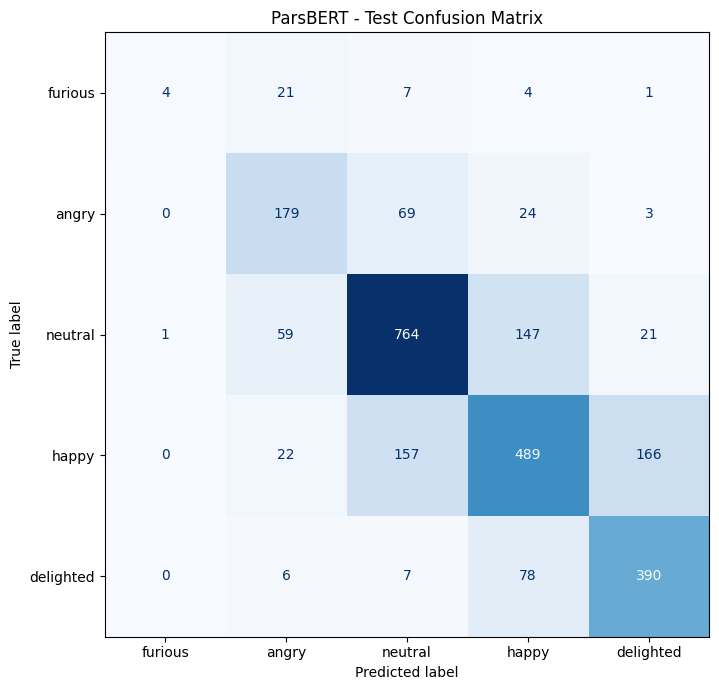

In [ ]:
# ================ #
# Confusion Matrix #
# ================ #

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    test_true_ids,
    test_pred_ids,
    labels=list(range(NUM_LABELS)),
)


fig, ax = plt.subplots(figsize=(8, 7))


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)


display.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False,
)


ax.set_title("ParsBERT - Test Confusion Matrix")

plt.tight_layout()


# ===================== #
# Save Confusion Matrix #
# ===================== #

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ================== #
# Save Final Metrics #
# ================== #

import json

with open(
    FINAL_METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_test_metrics,
        file,
        ensure_ascii=False,
        indent=4,
    )


print("Saved:", FINAL_METRICS_PATH)

Saved: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/metrics/test_metrics.json


In [ ]:
# =========================== #
# Final Evaluation Validation #
# =========================== #

required_outputs = [
    FINAL_METRICS_PATH,
    CLASSIFICATION_REPORT_PATH,
    TEST_PREDICTIONS_PATH,
    CONFUSION_MATRIX_PATH,
]


missing_outputs = [path for path in required_outputs if not path.exists()]


if missing_outputs:

    raise FileNotFoundError(
        "Missing final evaluation outputs:\n"
        + "\n".join(
            map(
                str,
                missing_outputs,
            )
        )
    )


# ========== #
# Step 14 Summary #
# ========== #

step14_summary = {
    "Status": "PASSED",
    "Test Samples": len(test_dataset),
    "Accuracy": round(
        test_accuracy,
        4,
    ),
    "Macro F1": round(
        test_macro_f1,
        4,
    ),
    "Weighted F1": round(
        test_weighted_f1,
        4,
    ),
    "Saved Outputs": len(required_outputs),
}


step14_summary

{'Status': 'PASSED',
 'Test Samples': 2619,
 'Accuracy': 0.6972,
 'Macro F1': 0.5896,
 'Weighted F1': 0.692,
 'Saved Outputs': 4}

## STEP 15 — Final Comparison Between ParsBERT and Linear SVM

The best Transformer model and the best classic model are compared on the same Test Set.


In [ ]:
# ================ #
# Comparison Paths #
# ================ #

COMPARISON_DIR = PARSBERT_OUTPUT_DIR / "comparison"

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


MODEL_COMPARISON_PATH = COMPARISON_DIR / "model_comparison.csv"

MODEL_COMPARISON_JSON_PATH = COMPARISON_DIR / "model_comparison.json"

MODEL_COMPARISON_PLOT_PATH = COMPARISON_DIR / "model_comparison.png"

In [ ]:
# ========== #
# Test Set Integrity #
# ========== #

classic_test_indices = pd.read_csv(INTERIM_DATA_DIR / "classic_test_indices.csv")


classic_indices = set(classic_test_indices["source_index"].astype(int))

parsbert_indices = set(test_df["source_index"].astype(int))


if classic_indices != parsbert_indices:

    raise ValueError("Linear SVM and ParsBERT " "do not share the same test set.")


# ================ #
# Test Set Summary #
# ================ #

comparison_test_check = {
    "Classic Test Samples": len(classic_indices),
    "ParsBERT Test Samples": len(parsbert_indices),
    "Common Samples": len(classic_indices & parsbert_indices),
    "Exact Match": (classic_indices == parsbert_indices),
}


comparison_test_check

{'Classic Test Samples': 2619,
 'ParsBERT Test Samples': 2619,
 'Common Samples': 2619,
 'Exact Match': True}

In [ ]:
# ===================== #
# Load ParsBERT Metrics #
# ===================== #

import json

with open(
    FINAL_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:

    parsbert_metrics = json.load(file)


required_metrics = [
    "accuracy",
    "macro_f1",
    "weighted_f1",
]


missing_metrics = [
    metric for metric in required_metrics if metric not in parsbert_metrics
]


if missing_metrics:

    raise KeyError("Missing ParsBERT metrics:\n" + "\n".join(missing_metrics))


parsbert_metrics

{'test_samples': 2619,
 'accuracy': 0.6972126765941199,
 'macro_f1': 0.5896079162455397,
 'weighted_f1': 0.6920408133086345,
 'evaluation_seconds': 3.962234583000054}

In [ ]:
# ======================= #
# Classical Result Search #
# ======================= #

import re


def normalize_name(value):

    value = str(value).strip().lower()

    return re.sub(
        r"[^a-z0-9]+",
        "_",
        value,
    ).strip("_")


metric_aliases = {
    "accuracy": {
        "accuracy",
        "test_accuracy",
        "holdout_accuracy",
        "acc",
    },
    "macro_f1": {
        "macro_f1",
        "test_macro_f1",
        "f1_macro",
        "macro_f1_score",
    },
    "weighted_f1": {
        "weighted_f1",
        "test_weighted_f1",
        "f1_weighted",
        "weighted_f1_score",
    },
}


candidate_rows = []


# ================== #
# Search CSV Outputs #
# ================== #

for csv_path in OUTPUTS_DIR.rglob("*.csv"):

    if PARSBERT_OUTPUT_DIR in csv_path.parents:
        continue

    try:

        candidate_df = pd.read_csv(csv_path)

    except Exception:

        continue

    normalized_columns = {
        normalize_name(column): column for column in candidate_df.columns
    }

    metric_columns = {}

    for metric_name, aliases in metric_aliases.items():

        matching_columns = [
            normalized_columns[alias]
            for alias in aliases
            if alias in normalized_columns
        ]

        if matching_columns:

            metric_columns[metric_name] = matching_columns[0]

    if len(metric_columns) != 3:
        continue

    model_column = None

    for candidate_name in [
        "model",
        "model_name",
        "classifier",
        "estimator",
    ]:

        if candidate_name in normalized_columns:

            model_column = normalized_columns[candidate_name]

            break

    rows_to_check = candidate_df.copy()

    if model_column is not None:

        svm_mask = (
            rows_to_check[model_column]
            .astype(str)
            .str.lower()
            .str.contains(
                "linear.*svm|svm.*linear",
                regex=True,
            )
        )

        if svm_mask.any():

            rows_to_check = rows_to_check[svm_mask]

    for row_index, row in rows_to_check.iterrows():

        try:

            result = {
                "path": str(csv_path),
                "row": int(row_index),
                "accuracy": float(row[metric_columns["accuracy"]]),
                "macro_f1": float(row[metric_columns["macro_f1"]]),
                "weighted_f1": float(row[metric_columns["weighted_f1"]]),
            }

        except Exception:

            continue

        score = 0

        path_text = str(csv_path).lower()

        if "classic" in path_text:
            score += 2

        if "svm" in path_text:
            score += 3

        if "linear" in path_text:
            score += 3

        if "test" in path_text:
            score += 2

        if "holdout" in path_text:
            score += 2

        if model_column is not None:

            model_text = str(row[model_column]).lower()

            if "linear" in model_text and "svm" in model_text:
                score += 10

        result["score"] = score

        candidate_rows.append(result)


# =============== #
# Candidate Table #
# =============== #

classic_candidates = pd.DataFrame(candidate_rows)


if classic_candidates.empty:

    raise FileNotFoundError("No saved Linear SVM metric " "artifact was detected.")


classic_candidates = classic_candidates.sort_values(
    "score",
    ascending=False,
).reset_index(drop=True)


classic_candidates.head(10)

,path,row,accuracy,macro_f1,weighted_f1,score
0,/content/drive/MyDrive/PersianSentimentProject...,0,0.604047,0.498735,0.599255,14
1,/content/drive/MyDrive/PersianSentimentProject...,21,0.613550,0.517732,0.608657,12
2,/content/drive/MyDrive/PersianSentimentProject...,20,0.614504,0.471280,0.608621,12
3,/content/drive/MyDrive/PersianSentimentProject...,22,0.612595,0.506643,0.608404,12
4,/content/drive/MyDrive/PersianSentimentProject...,23,0.611641,0.488359,0.606079,12
5,/content/drive/MyDrive/PersianSentimentProject...,25,0.623687,0.517474,0.619398,12
6,/content/drive/MyDrive/PersianSentimentProject...,24,0.625954,0.505964,0.621426,12
7,/content/drive/MyDrive/PersianSentimentProject...,26,0.641834,0.524235,0.638763,12
8,/content/drive/MyDrive/PersianSentimentProject...,27,0.600764,0.471714,0.595287,12
9,/content/drive/MyDrive/PersianSentimentProject...,28,0.596944,0.477172,0.592028,12


In [ ]:
# ======================== #
# Select Linear SVM Result #
# ======================== #

best_candidate = classic_candidates.iloc[0]


linear_svm_metrics = {
    "accuracy": float(best_candidate["accuracy"]),
    "macro_f1": float(best_candidate["macro_f1"]),
    "weighted_f1": float(best_candidate["weighted_f1"]),
}


# ================= #
# Selected Artifact #
# ================= #

selected_classic_result = {
    "Source": best_candidate["path"],
    "Accuracy": linear_svm_metrics["accuracy"],
    "Macro F1": linear_svm_metrics["macro_f1"],
    "Weighted F1": linear_svm_metrics["weighted_f1"],
}


selected_classic_result

{'Source': '/content/drive/MyDrive/PersianSentimentProject/outputs/tables/03_classic_models/holdout_model_comparison.csv',
 'Accuracy': 0.6040473463153876,
 'Macro F1': 0.4987346555051423,
 'Weighted F1': 0.5992554149761676}

In [ ]:
# ================ #
# Model Comparison #
# ================ #

comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Macro F1",
            "Weighted F1",
        ],
        "Linear SVM": [
            linear_svm_metrics["accuracy"],
            linear_svm_metrics["macro_f1"],
            linear_svm_metrics["weighted_f1"],
        ],
        "ParsBERT": [
            parsbert_metrics["accuracy"],
            parsbert_metrics["macro_f1"],
            parsbert_metrics["weighted_f1"],
        ],
    }
)


# ==================== #
# Absolute Improvement #
# ==================== #

comparison_df["Absolute Improvement"] = (
    comparison_df["ParsBERT"] - comparison_df["Linear SVM"]
)


# ==================== #
# Relative Improvement #
# ==================== #

comparison_df["Relative Improvement (%)"] = (
    comparison_df["Absolute Improvement"] / comparison_df["Linear SVM"] * 100
)


comparison_df

,Metric,Linear SVM,ParsBERT,Absolute Improvement,Relative Improvement (%)
0,Accuracy,0.604047,0.697213,0.093165,15.423515
1,Macro F1,0.498735,0.589608,0.090873,18.220763
2,Weighted F1,0.599255,0.692041,0.092785,15.483448


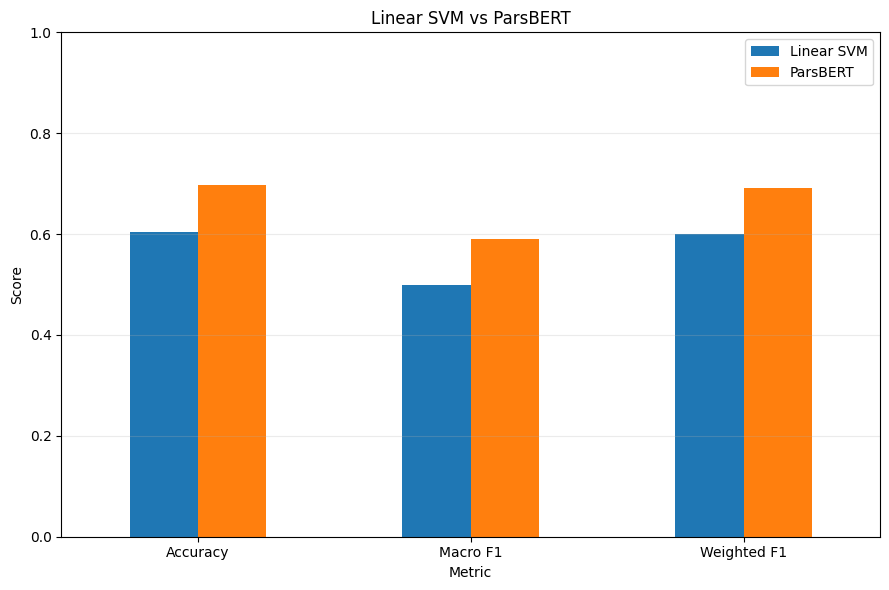

In [ ]:
# =============== #
# Save Comparison #
# =============== #

comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
)


comparison_records = comparison_df.to_dict(orient="records")


with open(
    MODEL_COMPARISON_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        comparison_records,
        file,
        ensure_ascii=False,
        indent=4,
    )


# =============== #
# Comparison Plot #
# =============== #

import matplotlib.pyplot as plt

plot_df = comparison_df[
    [
        "Metric",
        "Linear SVM",
        "ParsBERT",
    ]
].set_index("Metric")


ax = plot_df.plot(
    kind="bar",
    figsize=(9, 6),
)


ax.set_title("Linear SVM vs ParsBERT")

ax.set_ylabel("Score")

ax.set_ylim(
    0,
    1,
)

ax.grid(
    axis="y",
    alpha=0.25,
)


plt.xticks(rotation=0)

plt.tight_layout()


plt.savefig(
    MODEL_COMPARISON_PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()

In [ ]:
# ================== #
# Step 15 Validation #
# ================== #

required_comparison_outputs = [
    MODEL_COMPARISON_PATH,
    MODEL_COMPARISON_JSON_PATH,
    MODEL_COMPARISON_PLOT_PATH,
]


missing_outputs = [path for path in required_comparison_outputs if not path.exists()]


if missing_outputs:

    raise FileNotFoundError(
        "Missing comparison outputs:\n"
        + "\n".join(
            map(
                str,
                missing_outputs,
            )
        )
    )


macro_row = comparison_df[comparison_df["Metric"] == "Macro F1"].iloc[0]


# =============== #
# Step 15 Summary #
# =============== #

step15_summary = {
    "Status": "PASSED",
    "Test Samples": len(test_dataset),
    "Same Test Set": (classic_indices == parsbert_indices),
    "Linear SVM Macro F1": round(
        float(macro_row["Linear SVM"]),
        4,
    ),
    "ParsBERT Macro F1": round(
        float(macro_row["ParsBERT"]),
        4,
    ),
    "Macro F1 Improvement": round(
        float(macro_row["Absolute Improvement"]),
        4,
    ),
    "Relative Improvement (%)": round(
        float(macro_row["Relative Improvement (%)"]),
        2,
    ),
    "Saved Outputs": len(required_comparison_outputs),
}


step15_summary

{'Status': 'PASSED',
 'Test Samples': 2619,
 'Same Test Set': True,
 'Linear SVM Macro F1': 0.4987,
 'ParsBERT Macro F1': 0.5896,
 'Macro F1 Improvement': 0.0909,
 'Relative Improvement (%)': 18.22,
 'Saved Outputs': 3}

In [ ]:
# =========================== #
# ParsBERT Metric Consistency #
# =========================== #

print(
    "FINAL_METRICS_PATH:",
    FINAL_METRICS_PATH,
)


with open(
    FINAL_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:

    saved_parsbert_metrics = json.load(file)


print("\nSaved JSON:")

print(saved_parsbert_metrics)


print("\nIn-memory STEP 14:")

print(
    final_test_metrics
    if "final_test_metrics" in globals()
    else "Not available in memory"
)

FINAL_METRICS_PATH: /content/drive/MyDrive/PersianSentimentProject/outputs/04_parsbert/metrics/test_metrics.json

Saved JSON:
{'test_samples': 2619, 'accuracy': 0.6972126765941199, 'macro_f1': 0.5896079162455397, 'weighted_f1': 0.6920408133086345, 'evaluation_seconds': 3.962234583000054}

In-memory STEP 14:
{'test_samples': 2619, 'accuracy': 0.6972126765941199, 'macro_f1': 0.5896079162455397, 'weighted_f1': 0.6920408133086345, 'evaluation_seconds': 3.962234583000054}


In [ ]:
# ========================== #
# Recompute ParsBERT Metrics #
# ========================== #

saved_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)


recomputed_accuracy = accuracy_score(
    saved_predictions["label_id"],
    saved_predictions["predicted_label_id"],
)


recomputed_macro_f1 = f1_score(
    saved_predictions["label_id"],
    saved_predictions["predicted_label_id"],
    average="macro",
    zero_division=0,
)


recomputed_weighted_f1 = f1_score(
    saved_predictions["label_id"],
    saved_predictions["predicted_label_id"],
    average="weighted",
    zero_division=0,
)


recomputed_metrics = {
    "Accuracy": round(
        recomputed_accuracy,
        6,
    ),
    "Macro F1": round(
        recomputed_macro_f1,
        6,
    ),
    "Weighted F1": round(
        recomputed_weighted_f1,
        6,
    ),
}


recomputed_metrics

{'Accuracy': 0.697213, 'Macro F1': 0.589608, 'Weighted F1': 0.692041}

In [ ]:
# ======================== #
# Final Metric Consistency #
# ======================== #

assert np.isclose(
    parsbert_metrics["accuracy"],
    recomputed_accuracy,
)

assert np.isclose(
    parsbert_metrics["macro_f1"],
    recomputed_macro_f1,
)

assert np.isclose(
    parsbert_metrics["weighted_f1"],
    recomputed_weighted_f1,
)

print("Final ParsBERT metrics are consistent.")

Final ParsBERT metrics are consistent.


## STEP 16 — Comparative Error Analysis of Two Models

ParsBERT and Linear SVM errors are analyzed class-by-class and sample-by-sample on the shared Test Set.


In [ ]:
# ==================== #
# Error Analysis Paths #
# ==================== #

ERROR_ANALYSIS_DIR = PARSBERT_OUTPUT_DIR / "error_analysis"

ERROR_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CLASS_COMPARISON_PATH = ERROR_ANALYSIS_DIR / "per_class_comparison.csv"

PAIRED_PREDICTIONS_PATH = ERROR_ANALYSIS_DIR / "paired_predictions.csv"

DISAGREEMENTS_PATH = ERROR_ANALYSIS_DIR / "model_disagreements.csv"

ERROR_SUMMARY_PATH = ERROR_ANALYSIS_DIR / "error_analysis_summary.json"

CLASS_F1_PLOT_PATH = ERROR_ANALYSIS_DIR / "per_class_f1_comparison.png"

In [ ]:
# =========================== #
# Load Linear SVM Predictions #
# =========================== #

CLASSIC_ERROR_TABLE_PATH = (
    OUTPUTS_DIR / "tables" / "03_classic_models" / "error_analysis_table.csv"
)


if not CLASSIC_ERROR_TABLE_PATH.exists():

    raise FileNotFoundError(
        f"Classic prediction file not found:\n" f"{CLASSIC_ERROR_TABLE_PATH}"
    )


classic_predictions_df = pd.read_csv(CLASSIC_ERROR_TABLE_PATH)


# =================== #
# Artifact Validation #
# =================== #

required_columns = {
    "dataset_index",
    "actual_label",
    "predicted_label",
}


missing_columns = required_columns - set(classic_predictions_df.columns)


if missing_columns:

    raise ValueError(
        "Missing classic prediction columns:\n" + "\n".join(sorted(missing_columns))
    )


print(
    "Classic prediction rows:",
    len(classic_predictions_df),
)

print(
    "Classic prediction file:",
    CLASSIC_ERROR_TABLE_PATH,
)

Classic prediction rows: 2619
Classic prediction file: /content/drive/MyDrive/PersianSentimentProject/outputs/tables/03_classic_models/error_analysis_table.csv


In [ ]:
# ============================= #
# Normalize Classic Predictions #
# ============================= #

classic_pair_df = classic_predictions_df[
    [
        "dataset_index",
        "actual_label",
        "predicted_label",
    ]
].copy()


classic_pair_df = classic_pair_df.rename(
    columns={
        "dataset_index": "source_index",
        "actual_label": "svm_true_polarity",
        "predicted_label": "svm_predicted_polarity",
    }
)


# ============================ #
# Convert Polarity To Label ID #
# ============================ #

classic_pair_df["svm_true_label_id"] = (
    classic_pair_df["svm_true_polarity"].astype(int).map(LABEL_TO_ID)
)


classic_pair_df["svm_predicted_label_id"] = (
    classic_pair_df["svm_predicted_polarity"].astype(int).map(LABEL_TO_ID)
)


if (
    classic_pair_df[
        [
            "svm_true_label_id",
            "svm_predicted_label_id",
        ]
    ]
    .isna()
    .any()
    .any()
):

    raise ValueError("Classic polarity conversion failed.")


classic_pair_df["svm_true_label_id"] = classic_pair_df["svm_true_label_id"].astype(int)


classic_pair_df["svm_predicted_label_id"] = classic_pair_df[
    "svm_predicted_label_id"
].astype(int)


classic_pair_df.head()

,source_index,svm_true_polarity,svm_predicted_polarity,svm_true_label_id,svm_predicted_label_id
0,85,1,2,3,4
1,2771,-1,-1,1,1
2,11539,1,1,3,3
3,7610,0,0,2,2
4,193,1,-1,3,1


In [ ]:
# ====================== #
# Classic Test Integrity #
# ====================== #

classic_prediction_indices = set(classic_pair_df["source_index"].astype(int))


parsbert_prediction_indices = set(test_predictions_df["source_index"].astype(int))


if classic_prediction_indices != parsbert_prediction_indices:

    raise ValueError("Classic and ParsBERT prediction " "indices do not match.")


if len(classic_pair_df) != len(test_predictions_df):

    raise ValueError("Prediction row counts do not match.")


classic_prediction_check = {
    "Classic Samples": len(classic_pair_df),
    "ParsBERT Samples": len(test_predictions_df),
    "Common Samples": len(classic_prediction_indices & parsbert_prediction_indices),
    "Exact Match": (classic_prediction_indices == parsbert_prediction_indices),
}


classic_prediction_check

{'Classic Samples': 2619,
 'ParsBERT Samples': 2619,
 'Common Samples': 2619,
 'Exact Match': True}

In [ ]:
# ============================ #
# Prepare ParsBERT Predictions #
# ============================ #

parsbert_pair_df = test_predictions_df[
    [
        "source_index",
        TEXT_COLUMN,
        "label_id",
        "predicted_label_id",
        "confidence",
    ]
].copy()


parsbert_pair_df = parsbert_pair_df.rename(
    columns={
        "predicted_label_id": "parsbert_predicted_label_id",
        "confidence": "parsbert_confidence",
    }
)


# ================= #
# Merge Predictions #
# ================= #

paired_df = parsbert_pair_df.merge(
    classic_pair_df[
        [
            "source_index",
            "svm_true_label_id",
            "svm_predicted_label_id",
        ]
    ],
    on="source_index",
    how="inner",
    validate="one_to_one",
)


# ======================= #
# Ground Truth Validation #
# ======================= #

if not (
    paired_df["label_id"].to_numpy() == paired_df["svm_true_label_id"].to_numpy()
).all():

    raise ValueError("Ground-truth labels differ " "between the two experiments.")


if len(paired_df) != len(test_dataset):

    raise ValueError("Paired prediction count " "does not match the test set.")


# ================= #
# Correctness Flags #
# ================= #

paired_df["parsbert_correct"] = (
    paired_df["label_id"] == paired_df["parsbert_predicted_label_id"]
)


paired_df["svm_correct"] = paired_df["label_id"] == paired_df["svm_predicted_label_id"]


paired_df.head()

,source_index,text,label_id,parsbert_predicted_label_id,parsbert_confidence,svm_true_label_id,svm_predicted_label_id,parsbert_correct,svm_correct
0,85,مود Adv (Advanced) قابلیت‌های خیلی خوبی مثل ای...,3,4,0.936687,3,4,False,False
1,2771,رزولوشن صفحه اش پایینه در حالی که تبلت های 7 ا...,1,1,0.848126,1,1,True,True
2,11539,نکته جالب در مورد Nexus 4 این است که این گوشی ...,3,3,0.954404,3,3,True,True
3,7610,در تست‌های سخت افزاری انجام شده بر روی این گوش...,2,2,0.985194,2,2,True,True
4,193,واقعا نسبت به قیمتش ارزش داشت (البته اون موقع ...,3,3,0.717458,3,1,True,False


In [ ]:
# ================= #
# Per-Class Metrics #
# ================= #

from sklearn.metrics import (
    precision_recall_fscore_support,
)

y_true = paired_df["label_id"].to_numpy()

svm_pred = paired_df["svm_predicted_label_id"].to_numpy()

parsbert_pred = paired_df["parsbert_predicted_label_id"].to_numpy()


labels = list(range(NUM_LABELS))


svm_precision, svm_recall, svm_f1, support = precision_recall_fscore_support(
    y_true,
    svm_pred,
    labels=labels,
    zero_division=0,
)


pars_precision, pars_recall, pars_f1, _ = precision_recall_fscore_support(
    y_true,
    parsbert_pred,
    labels=labels,
    zero_division=0,
)


# ================ #
# Comparison Table #
# ================ #

per_class_df = pd.DataFrame(
    {
        "Label ID": labels,
        "Polarity": [ID_TO_LABEL[label_id] for label_id in labels],
        "Class": [ID_TO_NAME[label_id] for label_id in labels],
        "Support": support,
        "SVM Precision": svm_precision,
        "SVM Recall": svm_recall,
        "SVM F1": svm_f1,
        "ParsBERT Precision": pars_precision,
        "ParsBERT Recall": pars_recall,
        "ParsBERT F1": pars_f1,
    }
)


per_class_df["F1 Improvement"] = per_class_df["ParsBERT F1"] - per_class_df["SVM F1"]


per_class_df

,Label ID,Polarity,Class,Support,SVM Precision,SVM Recall,SVM F1,ParsBERT Precision,ParsBERT Recall,ParsBERT F1,F1 Improvement
0,0,-2,furious,37,0.357143,0.135135,0.196078,0.800000,0.108108,0.190476,-0.005602
1,1,-1,angry,275,0.418868,0.403636,0.411111,0.623693,0.650909,0.637011,0.225900
2,2,0,neutral,992,0.678469,0.714718,0.696122,0.760956,0.770161,0.765531,0.069409
3,3,1,happy,834,0.552632,0.503597,0.526976,0.659030,0.586331,0.620558,0.093582
4,4,2,delighted,481,0.629907,0.700624,0.663386,0.671256,0.810811,0.734463,0.071077


In [ ]:
# ======================= #
# Paired Error Categories #
# ======================= #

both_correct = paired_df["parsbert_correct"] & paired_df["svm_correct"]

parsbert_only = paired_df["parsbert_correct"] & ~paired_df["svm_correct"]

svm_only = ~paired_df["parsbert_correct"] & paired_df["svm_correct"]

both_wrong = ~paired_df["parsbert_correct"] & ~paired_df["svm_correct"]


# ============= #
# Error Summary #
# ============= #

paired_error_summary = {
    "Both Correct": int(both_correct.sum()),
    "ParsBERT Only Correct": int(parsbert_only.sum()),
    "Linear SVM Only Correct": int(svm_only.sum()),
    "Both Wrong": int(both_wrong.sum()),
}


paired_error_summary

{'Both Correct': 1362,
 'ParsBERT Only Correct': 464,
 'Linear SVM Only Correct': 220,
 'Both Wrong': 573}

In [ ]:
# ================== #
# McNemar Exact Test #
# ================== #

from scipy.stats import (
    binomtest,
)

parsbert_only_count = int(parsbert_only.sum())

svm_only_count = int(svm_only.sum())


discordant_count = parsbert_only_count + svm_only_count


if discordant_count > 0:

    mcnemar_result = binomtest(
        parsbert_only_count,
        n=discordant_count,
        p=0.5,
        alternative="two-sided",
    )

    mcnemar_p_value = float(mcnemar_result.pvalue)

else:

    mcnemar_p_value = 1.0


# =================== #
# Statistical Summary #
# =================== #

mcnemar_summary = {
    "ParsBERT Only Correct": (parsbert_only_count),
    "Linear SVM Only Correct": (svm_only_count),
    "Discordant Samples": (discordant_count),
    "McNemar Exact P-Value": (mcnemar_p_value),
}


mcnemar_summary

{'ParsBERT Only Correct': 464,
 'Linear SVM Only Correct': 220,
 'Discordant Samples': 684,
 'McNemar Exact P-Value': 5.852536822759162e-21}

In [ ]:
# ===================== #
# Disagreement Examples #
# ===================== #

disagreement_df = paired_df[parsbert_only | svm_only].copy()


disagreement_df["Winner"] = np.where(
    disagreement_df["parsbert_correct"],
    "ParsBERT",
    "Linear SVM",
)


disagreement_df["true_polarity"] = disagreement_df["label_id"].map(ID_TO_LABEL)


disagreement_df["parsbert_polarity"] = disagreement_df[
    "parsbert_predicted_label_id"
].map(ID_TO_LABEL)


disagreement_df["svm_polarity"] = disagreement_df["svm_predicted_label_id"].map(
    ID_TO_LABEL
)


disagreement_df = disagreement_df.sort_values(
    [
        "Winner",
        "parsbert_confidence",
    ],
    ascending=[
        True,
        False,
    ],
)


disagreement_df[
    [
        "source_index",
        TEXT_COLUMN,
        "true_polarity",
        "parsbert_polarity",
        "svm_polarity",
        "parsbert_confidence",
        "Winner",
    ]
].head(20)

,source_index,text,true_polarity,parsbert_polarity,svm_polarity,parsbert_confidence,Winner
1748,10528,این صفحه نمایش تصاویر را با رزولوشن 320×480 پی...,1,2,1,0.976954,Linear SVM
1102,6735,انرژی این دوربین از طریق دو باتری قلمی سایز AA...,0,1,0,0.976704,Linear SVM
1800,2883,لازم به ذکر است که ایسوس دلیل اصلی قرار دادن ا...,0,1,0,0.975609,Linear SVM
639,6750,PJ600 توانایی فیلم برداری Full HD را دارد و با...,1,2,1,0.973872,Linear SVM
2250,1894,(با یک کاور حل میشه!,1,0,1,0.970490,Linear SVM
1133,357,حافظه RAM این نوت‌بوک ها نیز بین 2 تا 4 گیگابا...,0,1,0,0.967978,Linear SVM
188,9289,این لنزها بیشتر مناسب ضبط ویدیویی و البته فوکو...,0,1,0,0.965316,Linear SVM
1940,1815,سبک و زیبا و پر قدرت!,1,2,1,0.965298,Linear SVM
1104,11145,همیشه اتصال به اینترنت با تلویزیون برای من مهم...,1,0,1,0.962503,Linear SVM
2022,9473,اگر در شرایط نوری خوب، بر روی یک سوژه بوسیله‌ی...,1,2,1,0.959712,Linear SVM


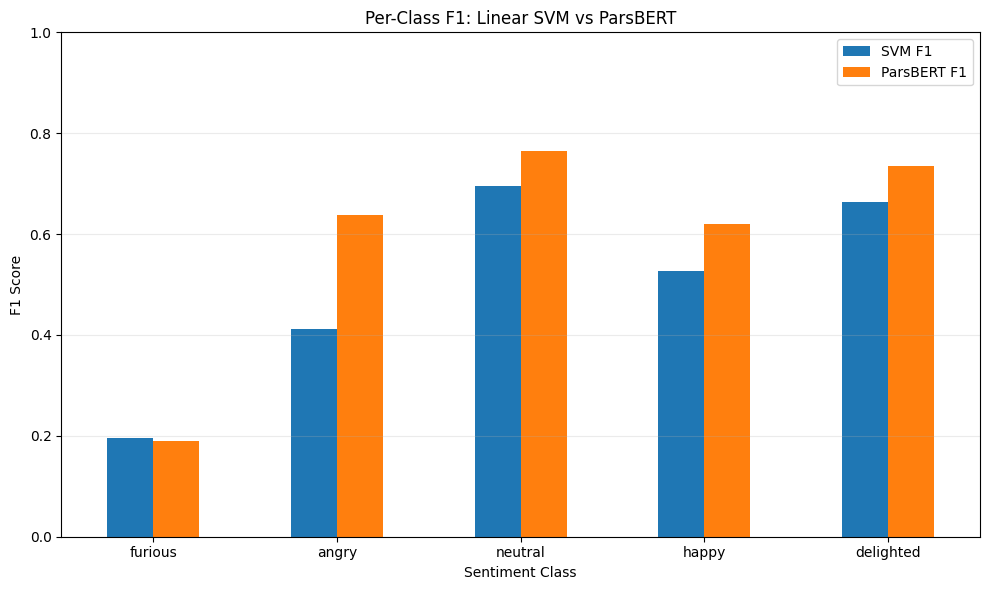

In [ ]:
# ================= #
# Per-Class F1 Plot #
# ================= #

import matplotlib.pyplot as plt

plot_df = per_class_df[
    [
        "Class",
        "SVM F1",
        "ParsBERT F1",
    ]
].set_index("Class")


ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)


ax.set_title("Per-Class F1: Linear SVM vs ParsBERT")

ax.set_xlabel("Sentiment Class")

ax.set_ylabel("F1 Score")

ax.set_ylim(
    0,
    1,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.xticks(rotation=0)

plt.tight_layout()


plt.savefig(
    CLASS_F1_PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ==================== #
# Save Analysis Tables #
# ==================== #

per_class_df.to_csv(
    CLASS_COMPARISON_PATH,
    index=False,
)

paired_df.to_csv(
    PAIRED_PREDICTIONS_PATH,
    index=False,
)

disagreement_df.to_csv(
    DISAGREEMENTS_PATH,
    index=False,
)


# ===================== #
# Save Analysis Summary #
# ===================== #

import json

analysis_summary = {
    "test_samples": int(len(paired_df)),
    "both_correct": int(both_correct.sum()),
    "parsbert_only_correct": int(parsbert_only.sum()),
    "svm_only_correct": int(svm_only.sum()),
    "both_wrong": int(both_wrong.sum()),
    "mcnemar_exact_p_value": (float(mcnemar_p_value)),
}


with open(
    ERROR_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        analysis_summary,
        file,
        ensure_ascii=False,
        indent=4,
    )

In [ ]:
# ================== #
# Step 16 Validation #
# ================== #

required_outputs = [
    CLASS_COMPARISON_PATH,
    PAIRED_PREDICTIONS_PATH,
    DISAGREEMENTS_PATH,
    ERROR_SUMMARY_PATH,
    CLASS_F1_PLOT_PATH,
]


missing_outputs = [path for path in required_outputs if not path.exists()]


if missing_outputs:

    raise FileNotFoundError(
        "Missing error analysis outputs:\n"
        + "\n".join(
            map(
                str,
                missing_outputs,
            )
        )
    )


best_improvement_row = per_class_df.loc[per_class_df["F1 Improvement"].idxmax()]


worst_improvement_row = per_class_df.loc[per_class_df["F1 Improvement"].idxmin()]


# =============== #
# Step 16 Summary #
# =============== #

step16_summary = {
    "Status": "PASSED",
    "Paired Test Samples": len(paired_df),
    "Both Correct": int(both_correct.sum()),
    "ParsBERT Only Correct": int(parsbert_only.sum()),
    "Linear SVM Only Correct": int(svm_only.sum()),
    "Both Wrong": int(both_wrong.sum()),
    "Largest F1 Gain Class": (best_improvement_row["Class"]),
    "Largest F1 Gain": round(
        float(best_improvement_row["F1 Improvement"]),
        4,
    ),
    "Smallest F1 Gain Class": (worst_improvement_row["Class"]),
    "Smallest F1 Gain": round(
        float(worst_improvement_row["F1 Improvement"]),
        4,
    ),
    "McNemar P-Value": float(mcnemar_p_value),
    "Saved Outputs": len(required_outputs),
}


step16_summary

{'Status': 'PASSED',
 'Paired Test Samples': 2619,
 'Both Correct': 1362,
 'ParsBERT Only Correct': 464,
 'Linear SVM Only Correct': 220,
 'Both Wrong': 573,
 'Largest F1 Gain Class': 'angry',
 'Largest F1 Gain': 0.2259,
 'Smallest F1 Gain Class': 'furious',
 'Smallest F1 Gain': -0.0056,
 'McNemar P-Value': 5.852536822759162e-21,
 'Saved Outputs': 5}

## STEP 17 — Save Final Model Results and Artifacts

Final models, evaluation reports, predictions, plots, and comparison results are saved for reproducibility and future usage.


In [ ]:
# ================== #
# Final Report Paths #
# ================== #

FINAL_TABLE_DIR = OUTPUTS_DIR / "tables" / "04_parsbert"

FINAL_REPORT_DIR = OUTPUTS_DIR / "reports" / "04_parsbert"


FINAL_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FINAL_COMPARISON_TABLE_PATH = FINAL_TABLE_DIR / "final_model_comparison.csv"

FINAL_CLASS_TABLE_PATH = FINAL_TABLE_DIR / "final_per_class_results.csv"

FINAL_SUMMARY_JSON_PATH = FINAL_REPORT_DIR / "final_results_summary.json"

FINAL_REPORT_PATH = FINAL_REPORT_DIR / "final_results_report.md"

In [ ]:
# ==================== #
# Load Final Artifacts #
# ==================== #

import json

comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)

per_class_df = pd.read_csv(CLASS_COMPARISON_PATH)


with open(
    FINAL_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:

    parsbert_final_metrics = json.load(file)


with open(
    ERROR_SUMMARY_PATH,
    "r",
    encoding="utf-8",
) as file:

    error_analysis_summary = json.load(file)


# =================== #
# Artifact Validation #
# =================== #

if len(comparison_df) != 3:

    raise ValueError("Unexpected model comparison table.")


if len(per_class_df) != NUM_LABELS:

    raise ValueError("Unexpected per-class result table.")


print("Final artifacts loaded successfully.")

Final artifacts loaded successfully.


In [ ]:
# ====================== #
# Final Comparison Table #
# ====================== #

final_comparison_df = comparison_df.copy()


final_comparison_df["Linear SVM"] = final_comparison_df["Linear SVM"].round(4)


final_comparison_df["ParsBERT"] = final_comparison_df["ParsBERT"].round(4)


final_comparison_df["Absolute Improvement"] = final_comparison_df[
    "Absolute Improvement"
].round(4)


final_comparison_df["Relative Improvement (%)"] = final_comparison_df[
    "Relative Improvement (%)"
].round(2)


final_comparison_df

,Metric,Linear SVM,ParsBERT,Absolute Improvement,Relative Improvement (%)
0,Accuracy,0.6040,0.6972,0.0932,15.42
1,Macro F1,0.4987,0.5896,0.0909,18.22
2,Weighted F1,0.5993,0.6920,0.0928,15.48


In [ ]:
# ======================= #
# Final Per-Class Results #
# ======================= #

final_class_df = per_class_df.copy()


metric_columns = [
    "SVM Precision",
    "SVM Recall",
    "SVM F1",
    "ParsBERT Precision",
    "ParsBERT Recall",
    "ParsBERT F1",
    "F1 Improvement",
]


for column in metric_columns:

    final_class_df[column] = final_class_df[column].round(4)


final_class_df

,Label ID,Polarity,Class,Support,SVM Precision,SVM Recall,SVM F1,ParsBERT Precision,ParsBERT Recall,ParsBERT F1,F1 Improvement
0,0,-2,furious,37,0.3571,0.1351,0.1961,0.8000,0.1081,0.1905,-0.0056
1,1,-1,angry,275,0.4189,0.4036,0.4111,0.6237,0.6509,0.6370,0.2259
2,2,0,neutral,992,0.6785,0.7147,0.6961,0.7610,0.7702,0.7655,0.0694
3,3,1,happy,834,0.5526,0.5036,0.5270,0.6590,0.5863,0.6206,0.0936
4,4,2,delighted,481,0.6299,0.7006,0.6634,0.6713,0.8108,0.7345,0.0711


In [ ]:
# ===================== #
# Key Result Extraction #
# ===================== #

accuracy_row = comparison_df[comparison_df["Metric"] == "Accuracy"].iloc[0]


macro_row = comparison_df[comparison_df["Metric"] == "Macro F1"].iloc[0]


weighted_row = comparison_df[comparison_df["Metric"] == "Weighted F1"].iloc[0]


best_class_row = per_class_df.loc[per_class_df["F1 Improvement"].idxmax()]


weakest_class_row = per_class_df.loc[per_class_df["F1 Improvement"].idxmin()]


# =================== #
# Statistical Results #
# =================== #

mcnemar_p_value = float(error_analysis_summary["mcnemar_exact_p_value"])


parsbert_only_correct = int(error_analysis_summary["parsbert_only_correct"])


svm_only_correct = int(error_analysis_summary["svm_only_correct"])

In [ ]:
# ====================== #
# Final Research Summary #
# ====================== #

final_results_summary = {
    "Dataset": {
        "Test Samples": int(parsbert_final_metrics["test_samples"]),
        "Number of Classes": NUM_LABELS,
        "Shared Test Set": True,
    },
    "Linear SVM": {
        "Accuracy": float(accuracy_row["Linear SVM"]),
        "Macro F1": float(macro_row["Linear SVM"]),
        "Weighted F1": float(weighted_row["Linear SVM"]),
    },
    "ParsBERT": {
        "Accuracy": float(accuracy_row["ParsBERT"]),
        "Macro F1": float(macro_row["ParsBERT"]),
        "Weighted F1": float(weighted_row["ParsBERT"]),
    },
    "Improvement": {
        "Accuracy": float(accuracy_row["Absolute Improvement"]),
        "Macro F1": float(macro_row["Absolute Improvement"]),
        "Weighted F1": float(weighted_row["Absolute Improvement"]),
        "Macro F1 Relative (%)": float(macro_row["Relative Improvement (%)"]),
    },
    "Error Analysis": {
        "ParsBERT Only Correct": (parsbert_only_correct),
        "Linear SVM Only Correct": (svm_only_correct),
        "Largest F1 Gain Class": (str(best_class_row["Class"])),
        "Largest F1 Gain": float(best_class_row["F1 Improvement"]),
        "Smallest F1 Gain Class": (str(weakest_class_row["Class"])),
        "Smallest F1 Gain": float(weakest_class_row["F1 Improvement"]),
    },
    "Statistical Test": {
        "Test": "McNemar Exact Test",
        "P-Value": (mcnemar_p_value),
        "Significant at 0.05": (mcnemar_p_value < 0.05),
    },
}


final_results_summary

{'Dataset': {'Test Samples': 2619,
  'Number of Classes': 5,
  'Shared Test Set': True},
 'Linear SVM': {'Accuracy': 0.6040473463153876,
  'Macro F1': 0.4987346555051423,
  'Weighted F1': 0.5992554149761676},
 'ParsBERT': {'Accuracy': 0.6972126765941199,
  'Macro F1': 0.5896079162455397,
  'Weighted F1': 0.6920408133086345},
 'Improvement': {'Accuracy': 0.0931653302787323,
  'Macro F1': 0.0908732607403973,
  'Weighted F1': 0.0927853983324669,
  'Macro F1 Relative (%)': 18.22076323297738},
 'Error Analysis': {'ParsBERT Only Correct': 464,
  'Linear SVM Only Correct': 220,
  'Largest F1 Gain Class': 'angry',
  'Largest F1 Gain': 0.2258995650454724,
  'Smallest F1 Gain Class': 'furious',
  'Smallest F1 Gain': -0.0056022408963585},
 'Statistical Test': {'Test': 'McNemar Exact Test',
  'P-Value': 5.852536822759162e-21,
  'Significant at 0.05': True}}

In [ ]:
# ================= #
# Save Final Tables #
# ================= #

final_comparison_df.to_csv(
    FINAL_COMPARISON_TABLE_PATH,
    index=False,
)

final_class_df.to_csv(
    FINAL_CLASS_TABLE_PATH,
    index=False,
)


# ================== #
# Save Final Summary #
# ================== #

with open(
    FINAL_SUMMARY_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_results_summary,
        file,
        ensure_ascii=False,
        indent=4,
    )


# ================== #
# Build Final Report #
# ================== #

final_report = f"""
# Final Results and Conclusion

## Model Performance

- Test samples: {int(parsbert_final_metrics["test_samples"])}
- Linear SVM Accuracy: {accuracy_row["Linear SVM"]:.4f}
- ParsBERT Accuracy: {accuracy_row["ParsBERT"]:.4f}
- Linear SVM Macro F1: {macro_row["Linear SVM"]:.4f}
- ParsBERT Macro F1: {macro_row["ParsBERT"]:.4f}
- Linear SVM Weighted F1: {weighted_row["Linear SVM"]:.4f}
- ParsBERT Weighted F1: {weighted_row["ParsBERT"]:.4f}

## Improvement

- Macro F1 absolute improvement: {macro_row["Absolute Improvement"]:.4f}
- Macro F1 relative improvement: {macro_row["Relative Improvement (%)"]:.2f}%

## Comparative Error Analysis

- ParsBERT only correct: {parsbert_only_correct}
- Linear SVM only correct: {svm_only_correct}
- Largest F1 gain class: {best_class_row["Class"]}
- Largest F1 gain: {best_class_row["F1 Improvement"]:.4f}
- Smallest F1 gain class: {weakest_class_row["Class"]}
- Smallest F1 gain: {weakest_class_row["F1 Improvement"]:.4f}

## Statistical Test

- Test: McNemar Exact Test
- P-value: {mcnemar_p_value:.6e}
- Significant at alpha = 0.05: {mcnemar_p_value < 0.05}

## Conclusion

ParsBERT achieved better overall performance than the Linear SVM baseline
on the identical held-out test set. The largest improvement was observed
for the {best_class_row["Class"]} sentiment class, while the
{weakest_class_row["Class"]} class showed the smallest change.

The paired McNemar exact test indicates that the difference in sample-level
prediction accuracy between the two models is statistically significant.
"""


# ================= #
# Save Final Report #
# ================= #

with open(
    FINAL_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:

    file.write(final_report.strip())


print("Final outputs saved successfully.")

Final outputs saved successfully.


In [ ]:
# ======================= #
# Final Output Validation #
# ======================= #

required_final_outputs = [
    FINAL_COMPARISON_TABLE_PATH,
    FINAL_CLASS_TABLE_PATH,
    FINAL_SUMMARY_JSON_PATH,
    FINAL_REPORT_PATH,
]


missing_final_outputs = [path for path in required_final_outputs if not path.exists()]


if missing_final_outputs:

    raise FileNotFoundError(
        "Missing final research outputs:\n"
        + "\n".join(
            map(
                str,
                missing_final_outputs,
            )
        )
    )


# ===================== #
# Final Research Status #
# ===================== #

step17_summary = {
    "Status": "PASSED",
    "Test Samples": int(parsbert_final_metrics["test_samples"]),
    "Best Classical Model": ("Linear SVM"),
    "Final Model": ("ParsBERT"),
    "Linear SVM Macro F1": round(
        float(macro_row["Linear SVM"]),
        4,
    ),
    "ParsBERT Macro F1": round(
        float(macro_row["ParsBERT"]),
        4,
    ),
    "Macro F1 Improvement": round(
        float(macro_row["Absolute Improvement"]),
        4,
    ),
    "McNemar Significant": (mcnemar_p_value < 0.05),
    "Saved Final Outputs": len(required_final_outputs),
}


step17_summary

{'Status': 'PASSED',
 'Test Samples': 2619,
 'Best Classical Model': 'Linear SVM',
 'Final Model': 'ParsBERT',
 'Linear SVM Macro F1': 0.4987,
 'ParsBERT Macro F1': 0.5896,
 'Macro F1 Improvement': 0.0909,
 'McNemar Significant': True,
 'Saved Final Outputs': 4}

## Conclusion — Final Transformer Model Results

In this notebook, ParsBERT was fine-tuned for Persian five-class sentiment analysis using the cleaned SentiPers dataset. The model was evaluated on a fixed Test Set and compared with the best classic machine learning baseline.

**Next step:** The experiment provides a complete comparison between traditional TF-IDF based models and Transformer-based language understanding using ParsBERT.
